# 💹 Currency Exchange Rate Forecasting
## SGD/USD & CNY/USD — Time Series Forecasting for Banking Operations

---

| | |
|---|---|
| **Industry** | Finance & Banking |
| **Domain** | Foreign Exchange (Forex) / Risk Management |
| **Author** | Akakinad |
| **Date** | February 2026 |
| **Status** | In Progress |

---

## Objective

A major banking institution seeks to enhance its currency forecasting capabilities to optimise currency reserves, manage foreign exchange (forex) risk, and support international trade and investment decisions. This project builds a comprehensive, end-to-end forecasting system for two strategically important currency pairs:

- 🇸🇬 **SGD/USD** — Singapore Dollar to US Dollar
- 🇨🇳 **CNY/USD** — Chinese Yuan to US Dollar

---

## Techniques

| Category | Models |
|---|---|
| **Statistical** | Holt-Winters, ARIMA, SARIMA, SARIMAX, VAR, VECM |
| **Forecasting Frameworks** | Facebook Prophet |
| **Machine Learning** | Decision Tree, Random Forest, SVR, XGBoost, LightGBM |
| **Deep Learning** | LSTM, GRU, Transformer |
| **Hybrid & Ensemble** | ARIMA-LSTM Hybrid, Ensemble Stacking |

---

## Evaluation Metrics

| Metric | Description |
|---|---|
| **RMSE** | Root Mean Squared Error — penalises large errors |
| **MAE** | Mean Absolute Error — average error in rate units |
| **MAPE** | Mean Absolute Percentage Error — interpretable % accuracy |
| **R²** | Proportion of variance explained by the model |
| **Directional Accuracy** | Whether the model correctly predicts rate direction (↑↓) |
| **Max Error** | Worst-case single prediction — critical for risk management |

---

## 1. Imports

In [1]:
# Standard Library
import warnings
import os
warnings.filterwarnings("ignore")

In [2]:
# Data Manipulation
import numpy as np
import pandas as pd

In [3]:
# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [4]:
# Interactive Visualisation
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [5]:
# Statistical & Time Series Models
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import ValueWarning
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=ValueWarning)

In [6]:
# Machine Learning
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    max_error
)
import xgboost as xgb
import lightgbm as lgb

In [7]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "sans-serif"
})

sns.set_palette("husl")

print("✅ All libraries loaded successfully")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   xgboost    : {xgb.__version__}")
print(f"   lightgbm   : {lgb.__version__}")

✅ All libraries loaded successfully
   pandas     : 3.0.1
   numpy      : 1.26.4
   xgboost    : 3.2.0
   lightgbm   : 4.6.0


## 2. Data Loading

In [8]:
# Load raw dataset
df = pd.read_csv("./data/Foreign_Exchange_Rates.csv")
print(f"Shape: {df.shape}")

Shape: (5217, 3)


In [9]:
# Preview first 5 rows
df.head()

,DATE,SINGAPORE - SINGAPORE DOLLAR/US$,CHINA - YUAN/US$
0,2000-01-03,1.6563,8.2798
1,2000-01-04,1.6535,8.2799
2,2000-01-05,1.656,8.2798
3,2000-01-06,1.6655,8.2797
4,2000-01-07,1.6625,8.2794


In [10]:
# Preview last 5 rows
df.tail()

,DATE,SINGAPORE - SINGAPORE DOLLAR/US$,CHINA - YUAN/US$
5212,2019-12-25,ND,ND
5213,2019-12-26,1.354,6.9949
5214,2019-12-27,1.352,6.9954
5215,2019-12-30,1.3483,6.9864
5216,2019-12-31,1.3446,6.9618


In [11]:
# Data types and structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 3 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   DATE                              5217 non-null   str  
 1   SINGAPORE - SINGAPORE DOLLAR/US$  5217 non-null   str  
 2   CHINA - YUAN/US$                  5217 non-null   str  
dtypes: str(3)
memory usage: 122.4 KB


In [12]:
# Statistical summary
df.describe()

,DATE,SINGAPORE - SINGAPORE DOLLAR/US$,CHINA - YUAN/US$
count,5217,5217,5217
unique,5217,2927,2711
top,2000-01-03,ND,8.2765
freq,1,198,208


In [13]:
# Check for ND values explicitly
print(f"ND in SGD column: {(df['SINGAPORE - SINGAPORE DOLLAR/US$'] == 'ND').sum()}")
print(f"ND in CNY column: {(df['CHINA - YUAN/US$'] == 'ND').sum()}")

ND in SGD column: 198
ND in CNY column: 197


## 3. Data Cleaning

In [14]:
# Rename columns
df.columns = ["date", "sgd_usd", "cny_usd"]
df.columns

Index(['date', 'sgd_usd', 'cny_usd'], dtype='str')

In [15]:
# Replace ND with NaN
df.replace("ND", np.nan, inplace=True)
print("Done")

Done


In [16]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])
df["date"].dtype

dtype('<M8[us]')

In [17]:
# Convert rate columns to float
df["sgd_usd"] = df["sgd_usd"].astype(float)
df["cny_usd"] = df["cny_usd"].astype(float)
df.dtypes

date       datetime64[us]
sgd_usd           float64
cny_usd           float64
dtype: object

In [18]:
# Set date as index and sort
df.set_index("date", inplace=True)
df.sort_index(inplace=True)
df.head()

,sgd_usd,cny_usd
date,,
2000-01-03,1.656300,8.279800
2000-01-04,1.653500,8.279900
2000-01-05,1.656000,8.279800
2000-01-06,1.665500,8.279700
2000-01-07,1.662500,8.279400


In [19]:
# Verify missing values after cleaning
print(f"SGD missing: {df['sgd_usd'].isnull().sum()}")
print(f"CNY missing: {df['cny_usd'].isnull().sum()}")

SGD missing: 198
CNY missing: 197


In [20]:
# Forward fill missing values (standard practice for financial time series)
df.ffill(inplace=True)

# Verify
print(f"SGD missing after fill: {df['sgd_usd'].isnull().sum()}")
print(f"CNY missing after fill: {df['cny_usd'].isnull().sum()}")

SGD missing after fill: 0
CNY missing after fill: 0


In [21]:
# Final cleaned dataframe overview
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5217 entries, 2000-01-03 to 2019-12-31
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   sgd_usd  5217 non-null   float64
 1   cny_usd  5217 non-null   float64
dtypes: float64(2)
memory usage: 122.3 KB


In [22]:
# Final statistical summary of cleaned data
df.describe()

,sgd_usd,cny_usd
count,5217.000000,5217.000000
mean,1.480183,7.199286
std,0.188831,0.819876
min,1.200700,6.040200
25%,1.342600,6.475800
50%,1.408400,6.859700
75%,1.678700,8.276500
max,1.854000,8.280000


## 4. Exploratory Data Analysis (EDA)

In [23]:
# Shape of cleaned data before EDA
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Total days : {len(df)}")
print(f"Columns    : {df.columns.tolist()}")

Date range : 2000-01-03 → 2019-12-31
Total days : 5217
Columns    : ['sgd_usd', 'cny_usd']


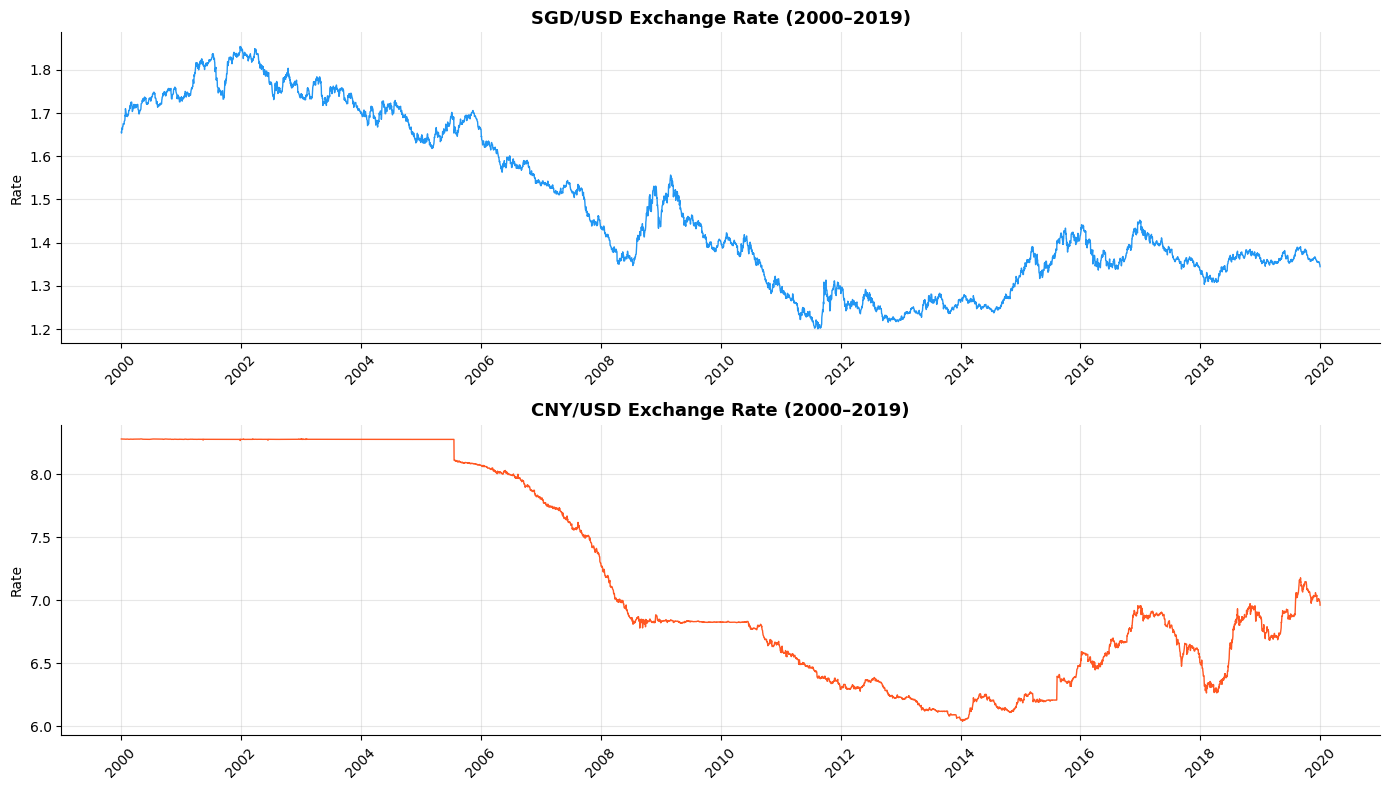

In [24]:
# Plot raw exchange rates over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, df["sgd_usd"], color="#2196F3", linewidth=1)
axes[0].set_title("SGD/USD Exchange Rate (2000–2019)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")

axes[1].plot(df.index, df["cny_usd"], color="#FF5722", linewidth=1)
axes[1].set_title("CNY/USD Exchange Rate (2000–2019)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/01_raw_exchange_rates.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# 30-day rolling mean and standard deviation
df["sgd_roll_mean"] = df["sgd_usd"].rolling(window=30).mean()
df["sgd_roll_std"]  = df["sgd_usd"].rolling(window=30).std()

df["cny_roll_mean"] = df["cny_usd"].rolling(window=30).mean()
df["cny_roll_std"]  = df["cny_usd"].rolling(window=30).std()

df[["sgd_roll_mean", "sgd_roll_std", "cny_roll_mean", "cny_roll_std"]].head(35)

,sgd_roll_mean,sgd_roll_std,cny_roll_mean,cny_roll_std
date,,,,
2000-01-03,NaN,NaN,NaN,NaN
2000-01-04,NaN,NaN,NaN,NaN
2000-01-05,NaN,NaN,NaN,NaN
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,NaN,NaN,NaN,NaN
2000-01-13,NaN,NaN,NaN,NaN


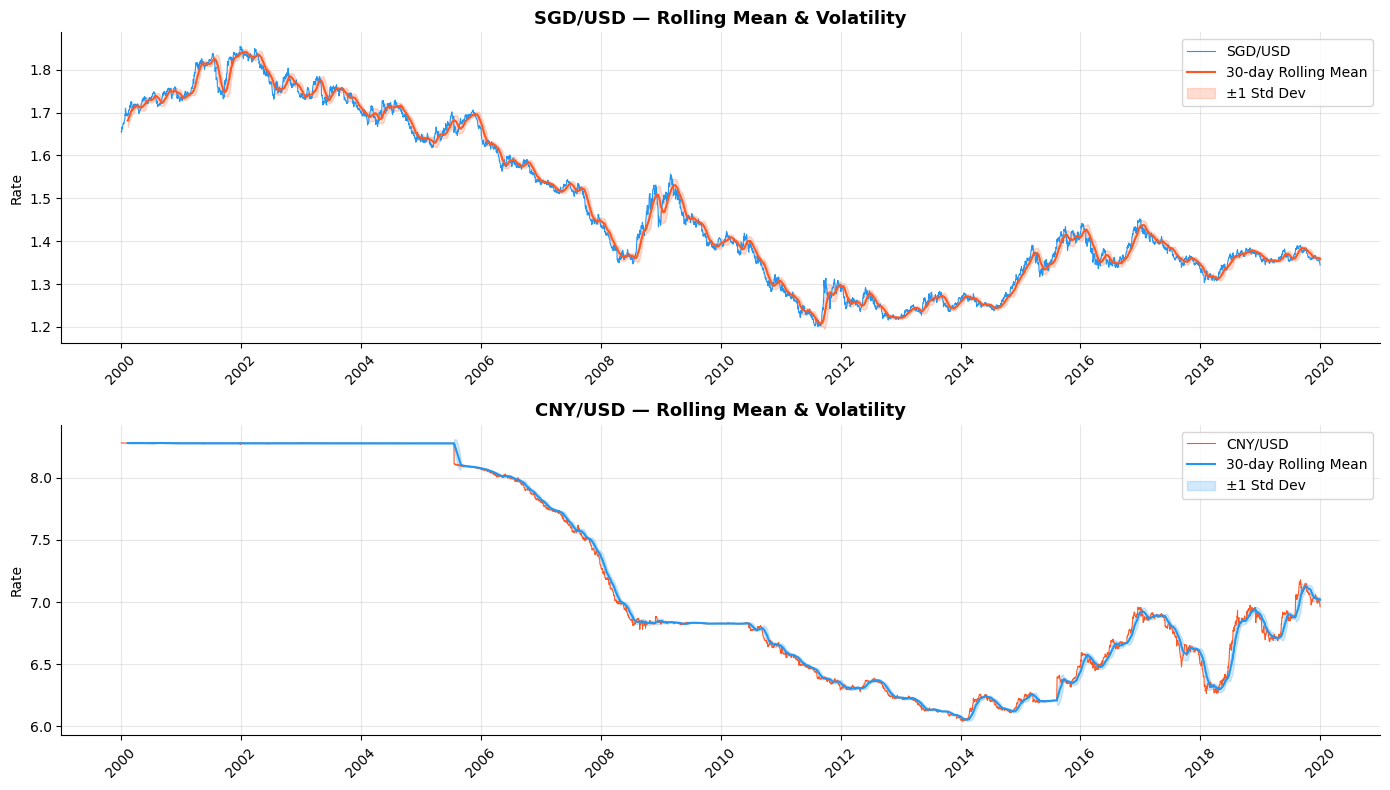

In [26]:
# Plot rolling mean and std for SGD
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df["sgd_usd"], color="#2196F3", linewidth=0.8, label="SGD/USD")
axes[0].plot(df["sgd_roll_mean"], color="#FF5722", linewidth=1.5, label="30-day Rolling Mean")
axes[0].fill_between(df.index,
                     df["sgd_roll_mean"] - df["sgd_roll_std"],
                     df["sgd_roll_mean"] + df["sgd_roll_std"],
                     alpha=0.2, color="#FF5722", label="±1 Std Dev")
axes[0].set_title("SGD/USD — Rolling Mean & Volatility", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(df["cny_usd"], color="#FF5722", linewidth=0.8, label="CNY/USD")
axes[1].plot(df["cny_roll_mean"], color="#2196F3", linewidth=1.5, label="30-day Rolling Mean")
axes[1].fill_between(df.index,
                     df["cny_roll_mean"] - df["cny_roll_std"],
                     df["cny_roll_mean"] + df["cny_roll_std"],
                     alpha=0.2, color="#2196F3", label="±1 Std Dev")
axes[1].set_title("CNY/USD — Rolling Mean & Volatility", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/02_rolling_stats.png", dpi=150, bbox_inches="tight")
plt.show()

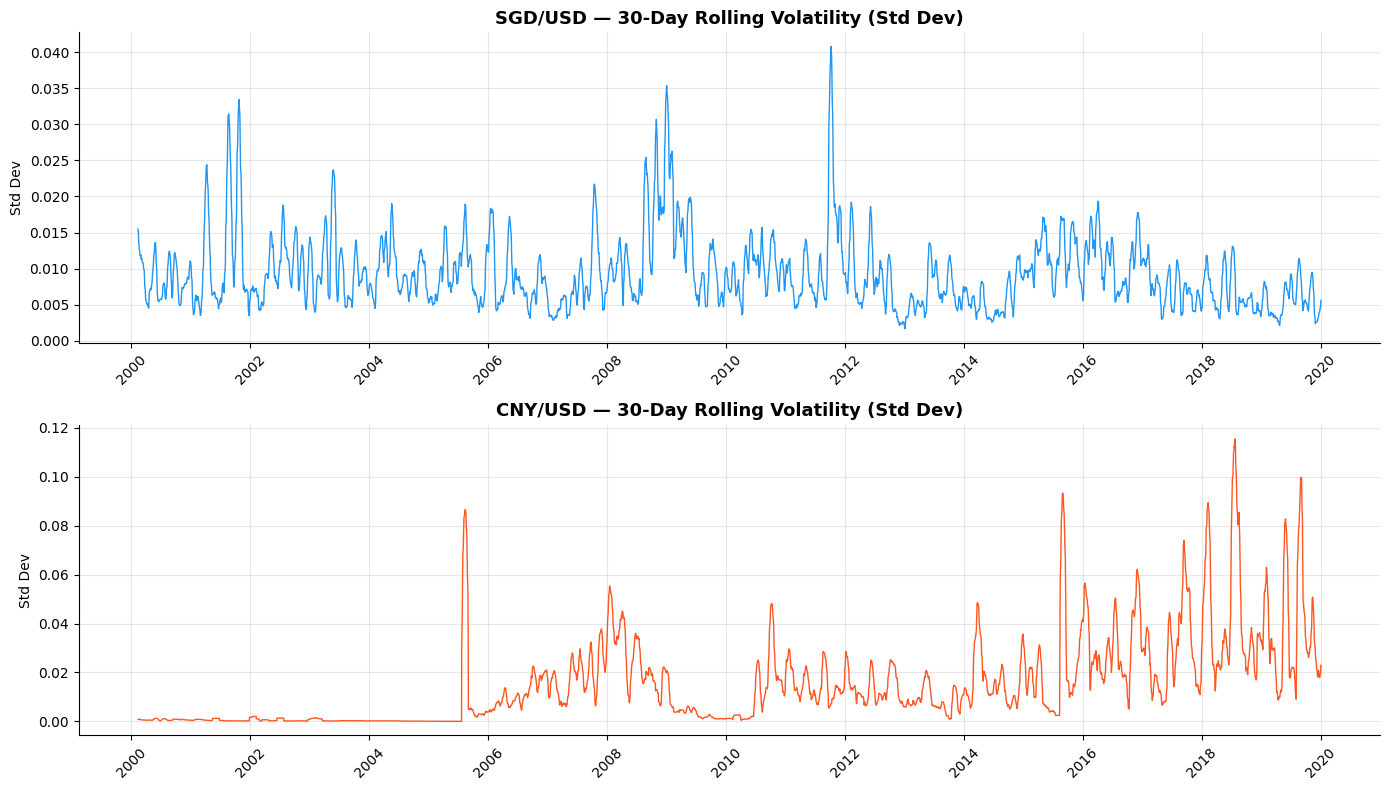

In [27]:
# Plot volatility (rolling std) separately for clarity
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df["sgd_roll_std"], color="#2196F3", linewidth=1)
axes[0].set_title("SGD/USD — 30-Day Rolling Volatility (Std Dev)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Std Dev")

axes[1].plot(df["cny_roll_std"], color="#FF5722", linewidth=1)
axes[1].set_title("CNY/USD — 30-Day Rolling Volatility (Std Dev)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Std Dev")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/03_rolling_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# Correlation between SGD and CNY
correlation = df[["sgd_usd", "cny_usd"]].corr()
print(correlation)

         sgd_usd  cny_usd
sgd_usd 1.000000 0.955555
cny_usd 0.955555 1.000000


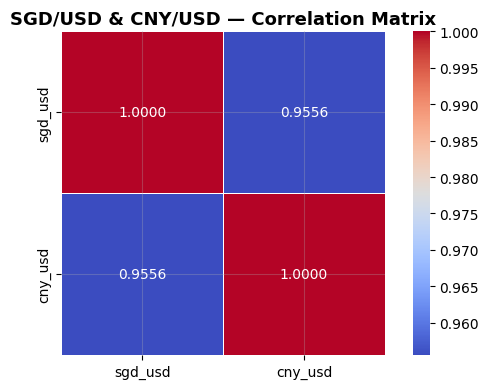

In [29]:
# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, 
            annot=True, 
            fmt=".4f", 
            cmap="coolwarm", 
            linewidths=0.5,
            square=True)
plt.title("SGD/USD & CNY/USD — Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("./reports/04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

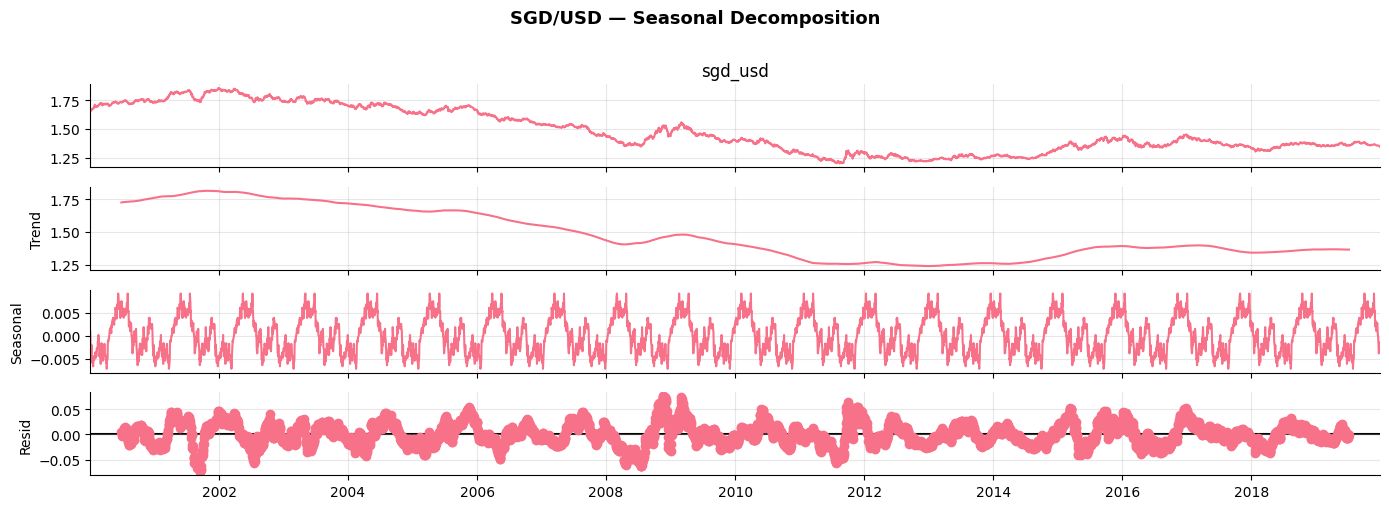

In [30]:
# Seasonal decomposition — SGD/USD
decomp_sgd = seasonal_decompose(df["sgd_usd"], model="additive", period=252)
decomp_sgd.plot()
plt.suptitle("SGD/USD — Seasonal Decomposition", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./reports/05_decomp_sgd.png", dpi=150, bbox_inches="tight")
plt.show()

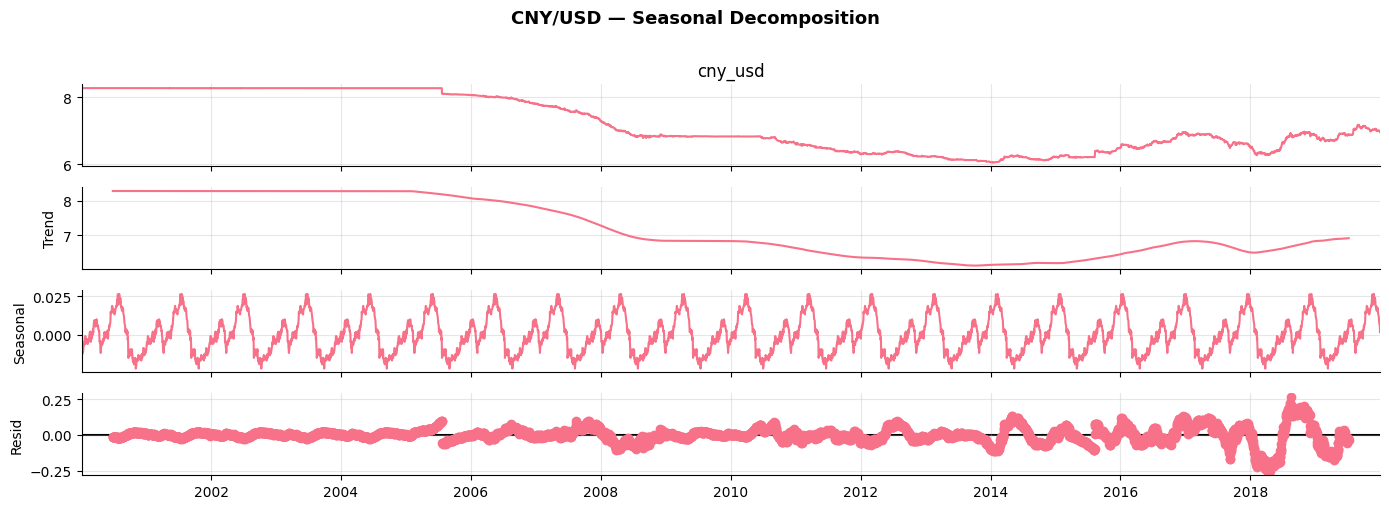

In [31]:
# Seasonal decomposition — CNY/USD
decomp_cny = seasonal_decompose(df["cny_usd"], model="additive", period=252)
decomp_cny.plot()
plt.suptitle("CNY/USD — Seasonal Decomposition", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./reports/06_decomp_cny.png", dpi=150, bbox_inches="tight")
plt.show()

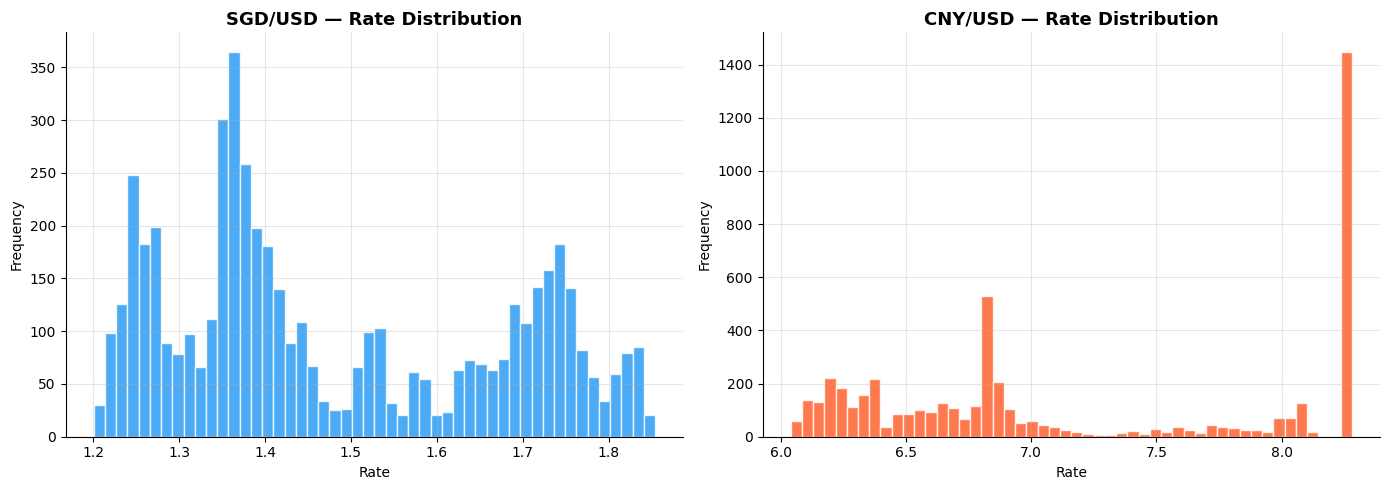

In [32]:
# Distribution of exchange rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["sgd_usd"], bins=50, color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].set_title("SGD/USD — Rate Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Rate")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["cny_usd"], bins=50, color="#FF5722", edgecolor="white", alpha=0.8)
axes[1].set_title("CNY/USD — Rate Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Rate")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("./reports/07_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 1600x500 with 0 Axes>

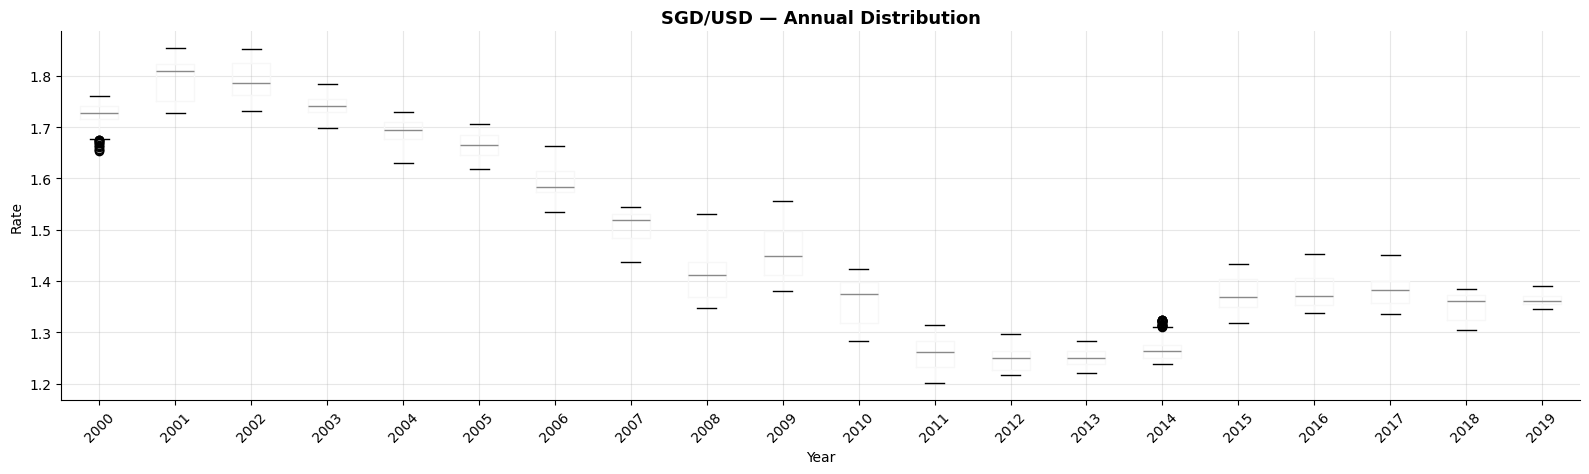

In [33]:
# Annual box plots — SGD
df_plot = df.copy()
df_plot["year"] = df_plot.index.year

plt.figure(figsize=(16, 5))
df_plot.boxplot(column="sgd_usd", by="year", figsize=(16, 5))
plt.title("SGD/USD — Annual Distribution", fontsize=13, fontweight="bold")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./reports/08_annual_boxplot_sgd.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 1600x500 with 0 Axes>

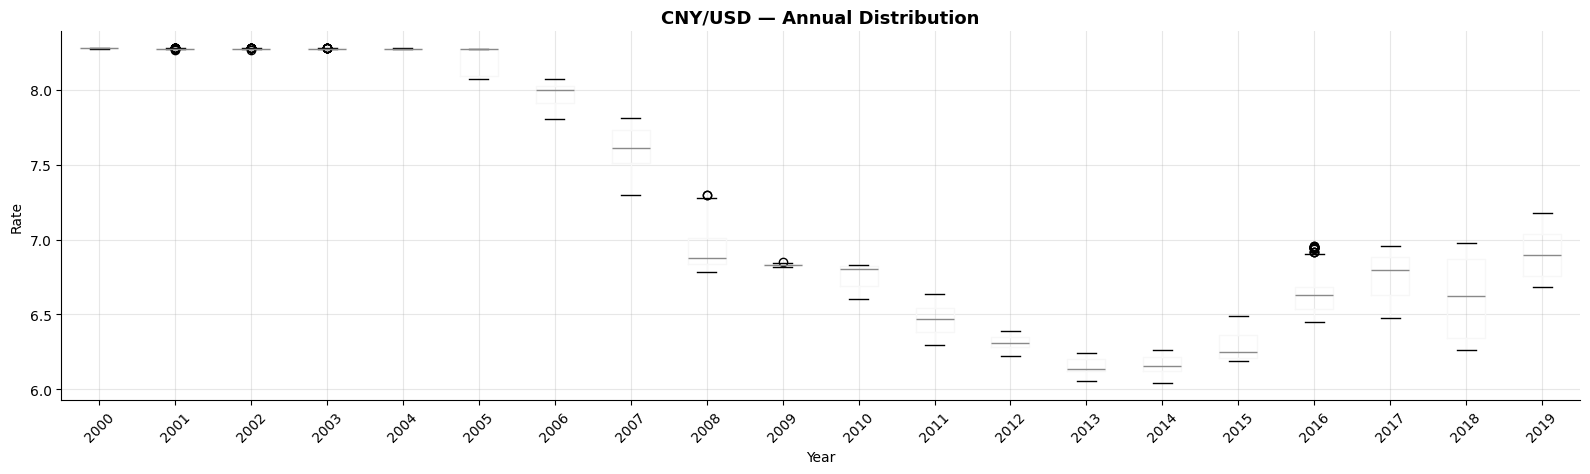

In [34]:
# Annual box plots — CNY
plt.figure(figsize=(16, 5))
df_plot.boxplot(column="cny_usd", by="year", figsize=(16, 5))
plt.title("CNY/USD — Annual Distribution", fontsize=13, fontweight="bold")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./reports/09_annual_boxplot_cny.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
# Daily percentage change (returns)
df["sgd_returns"] = df["sgd_usd"].pct_change() * 100
df["cny_returns"] = df["cny_usd"].pct_change() * 100

print(df[["sgd_returns", "cny_returns"]].describe())

       sgd_returns  cny_returns
count  5216.000000  5216.000000
mean     -0.003481    -0.003226
std       0.321366     0.139901
min      -2.356683    -1.998429
25%      -0.172249    -0.026243
50%       0.000000     0.000000
75%       0.159309     0.014936
max       2.731554     1.832705


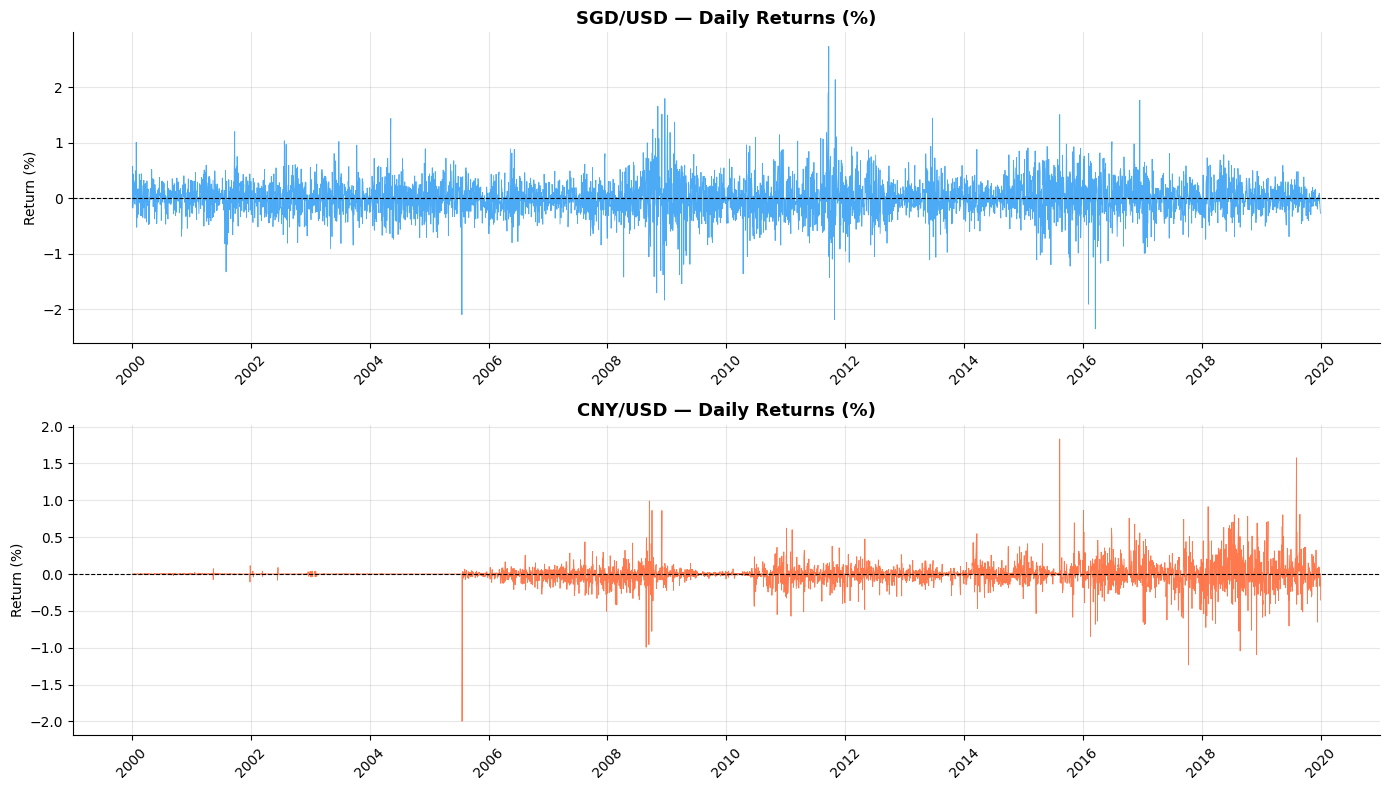

In [36]:
# Plot daily returns
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df["sgd_returns"], color="#2196F3", linewidth=0.6, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("SGD/USD — Daily Returns (%)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Return (%)")

axes[1].plot(df["cny_returns"], color="#FF5722", linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("CNY/USD — Daily Returns (%)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Return (%)")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/10_daily_returns.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Stationarity Testing

A time series is **stationary** when its statistical properties — mean, variance, and 
autocorrelation — remain constant over time. Most classical time series models (ARIMA, SARIMA, 
VAR) require stationarity to produce reliable forecasts. A non-stationary series has trends 
or changing variance that violate these assumptions.

We apply two complementary tests to rigorously assess stationarity:

---

### ADF — Augmented Dickey-Fuller Test
Tests whether the series has a **unit root** (a sign of non-stationarity).
- **H₀ (Null):** The series IS non-stationary (has a unit root)
- **p-value < 0.05** → Reject H₀ → Series IS stationary ✅
- **p-value > 0.05** → Fail to reject H₀ → Series IS NOT stationary ❌

### KPSS — Kwiatkowski-Phillips-Schmidt-Shin Test
The philosophical opposite of ADF — assumes stationarity unless proven otherwise.
- **H₀ (Null):** The series IS stationary
- **p-value < 0.05** → Reject H₀ → Series IS NOT stationary ❌
- **p-value > 0.05** → Fail to reject H₀ → Series IS stationary ✅

---

### Why Run Both?
Running only one test can be misleading. Together they give a definitive conclusion:

| ADF | KPSS | Conclusion |
|---|---|---|
| p < 0.05 | p > 0.05 | Stationary ✅ |
| p > 0.05 | p < 0.05 | Non-Stationary ❌ |
| p < 0.05 | p < 0.05 | Trend Stationary ⚠️ |
| p > 0.05 | p > 0.05 | Difference Stationary ⚠️ |

---

### Why Does This Matter for Our Project?
If either currency series is non-stationary, we must apply **first-order differencing** 
(subtracting each value from the previous one) to remove the trend before modelling. 
The number of times we difference the series determines the **d** parameter in ARIMA(p, d, q).

In [37]:
# ADF Test — SGD/USD  ADF — Augmented Dickey-Fuller Test:
adf_sgd = adfuller(df["sgd_usd"], autolag="AIC")

print("── ADF Test: SGD/USD ───────────────────────")
print(f"Test Statistic : {adf_sgd[0]:.4f}")
print(f"p-value        : {adf_sgd[1]:.4f}")
print(f"Lags Used      : {adf_sgd[2]}")
print(f"Critical Values:")
for key, val in adf_sgd[4].items():
    print(f"   {key}: {val:.4f}")

── ADF Test: SGD/USD ───────────────────────
Test Statistic : -1.0724
p-value        : 0.7259
Lags Used      : 8
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671


In [38]:
# ADF Test — CNY/USD
adf_cny = adfuller(df["cny_usd"], autolag="AIC")

print("── ADF Test: CNY/USD ───────────────────────")
print(f"Test Statistic : {adf_cny[0]:.4f}")
print(f"p-value        : {adf_cny[1]:.4f}")
print(f"Lags Used      : {adf_cny[2]}")
print(f"Critical Values:")
for key, val in adf_cny[4].items():
    print(f"   {key}: {val:.4f}")

── ADF Test: CNY/USD ───────────────────────
Test Statistic : -1.2844
p-value        : 0.6363
Lags Used      : 32
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671


In [39]:
# KPSS Test — SGD/USD. KPSS — Kwiatkowski-Phillips-Schmidt-Shin Test:
kpss_sgd = kpss(df["sgd_usd"], regression="c", nlags="auto")

print("── KPSS Test: SGD/USD ──────────────────────")
print(f"Test Statistic : {kpss_sgd[0]:.4f}")
print(f"p-value        : {kpss_sgd[1]:.4f}")
print(f"Lags Used      : {kpss_sgd[2]}")
print(f"Critical Values:")
for key, val in kpss_sgd[3].items():
    print(f"   {key}: {val:.4f}")

── KPSS Test: SGD/USD ──────────────────────
Test Statistic : 9.5299
p-value        : 0.0100
Lags Used      : 43
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/j8/w9fp7wn567n6kd2y98bl3whm0000gn/T/ipykernel_29661/768409818.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_sgd = kpss(df["sgd_usd"], regression="c", nlags="auto")


In [40]:
# KPSS Test — CNY/USD
kpss_cny = kpss(df["cny_usd"], regression="c", nlags="auto")

print("── KPSS Test: CNY/USD ──────────────────────")
print(f"Test Statistic : {kpss_cny[0]:.4f}")
print(f"p-value        : {kpss_cny[1]:.4f}")
print(f"Lags Used      : {kpss_cny[2]}")
print(f"Critical Values:")
for key, val in kpss_cny[3].items():
    print(f"   {key}: {val:.4f}")

── KPSS Test: CNY/USD ──────────────────────
Test Statistic : 9.8033
p-value        : 0.0100
Lags Used      : 43
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


/var/folders/j8/w9fp7wn567n6kd2y98bl3whm0000gn/T/ipykernel_29661/3376268060.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_cny = kpss(df["cny_usd"], regression="c", nlags="auto")


In [41]:
# First order differencing
df["sgd_diff"] = df["sgd_usd"].diff()
df["cny_diff"] = df["cny_usd"].diff()

df[["sgd_diff", "cny_diff"]].head(10)

,sgd_diff,cny_diff
date,,
2000-01-03,NaN,NaN
2000-01-04,-0.002800,0.000100
2000-01-05,0.002500,-0.000100
2000-01-06,0.009500,-0.000100
2000-01-07,-0.003000,-0.000300
2000-01-10,-0.000700,0.000000
2000-01-11,0.007200,0.000100
2000-01-12,0.000000,0.000100
2000-01-13,0.001000,0.000200


In [42]:
# ADF on differenced SGD
adf_sgd_diff = adfuller(df["sgd_diff"].dropna(), autolag="AIC")

print("── ADF Test: SGD/USD (Differenced) ─────────")
print(f"Test Statistic : {adf_sgd_diff[0]:.4f}")
print(f"p-value        : {adf_sgd_diff[1]:.4f}")
print(f"Critical Values:")
for key, val in adf_sgd_diff[4].items():
    print(f"   {key}: {val:.4f}")

── ADF Test: SGD/USD (Differenced) ─────────
Test Statistic : -23.8110
p-value        : 0.0000
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671


In [43]:
# ADF on differenced CNY
adf_cny_diff = adfuller(df["cny_diff"].dropna(), autolag="AIC")

print("── ADF Test: CNY/USD (Differenced) ─────────")
print(f"Test Statistic : {adf_cny_diff[0]:.4f}")
print(f"p-value        : {adf_cny_diff[1]:.4f}")
print(f"Critical Values:")
for key, val in adf_cny_diff[4].items():
    print(f"   {key}: {val:.4f}")

── ADF Test: CNY/USD (Differenced) ─────────
Test Statistic : -9.9092
p-value        : 0.0000
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671


## 6. ACF & PACF Analysis

Before fitting ARIMA models, we need to determine the optimal lag orders **p** (autoregressive term) 
and **q** (moving average term).

- **ACF (Autocorrelation Function):** measures the correlation between the series and its lagged 
  values at every lag. Used to identify the MA order **q** — the point where ACF drops sharply 
  to zero indicates the appropriate q value.

- **PACF (Partial Autocorrelation Function):** measures the direct correlation between the series 
  and a specific lag, removing the influence of all intermediate lags. Used to identify the AR 
  order **p** — the point where PACF cuts off sharply indicates the appropriate p value.

Since both series are confirmed I(1), we plot ACF and PACF on the **differenced series** 
to identify parameters for ARIMA(p, 1, q).

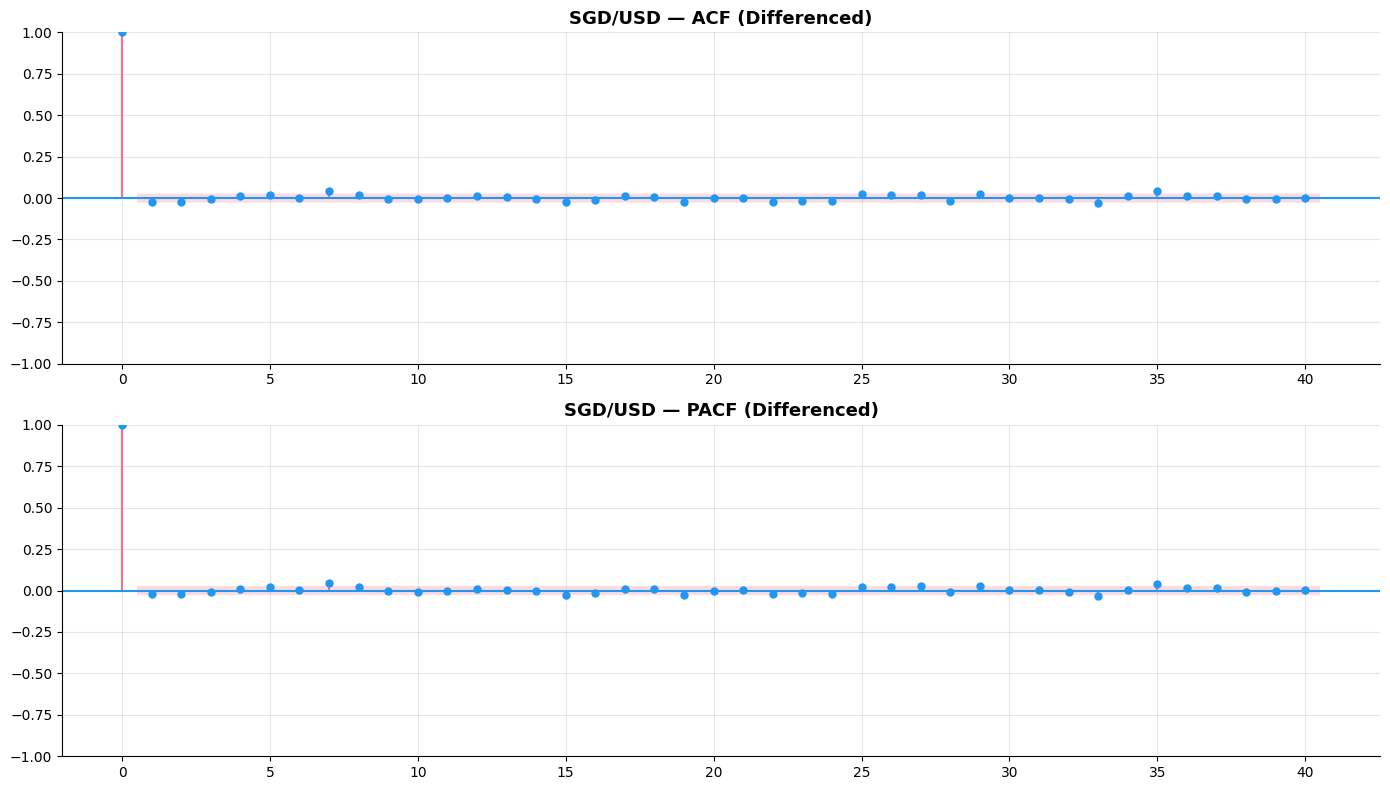

In [44]:
# ACF & PACF — SGD/USD (Differenced)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df["sgd_diff"].dropna(), lags=40, ax=axes[0], color="#2196F3")
axes[0].set_title("SGD/USD — ACF (Differenced)", fontsize=13, fontweight="bold")

plot_pacf(df["sgd_diff"].dropna(), lags=40, ax=axes[1], color="#2196F3")
axes[1].set_title("SGD/USD — PACF (Differenced)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("./reports/11_acf_pacf_sgd.png", dpi=150, bbox_inches="tight")
plt.show()

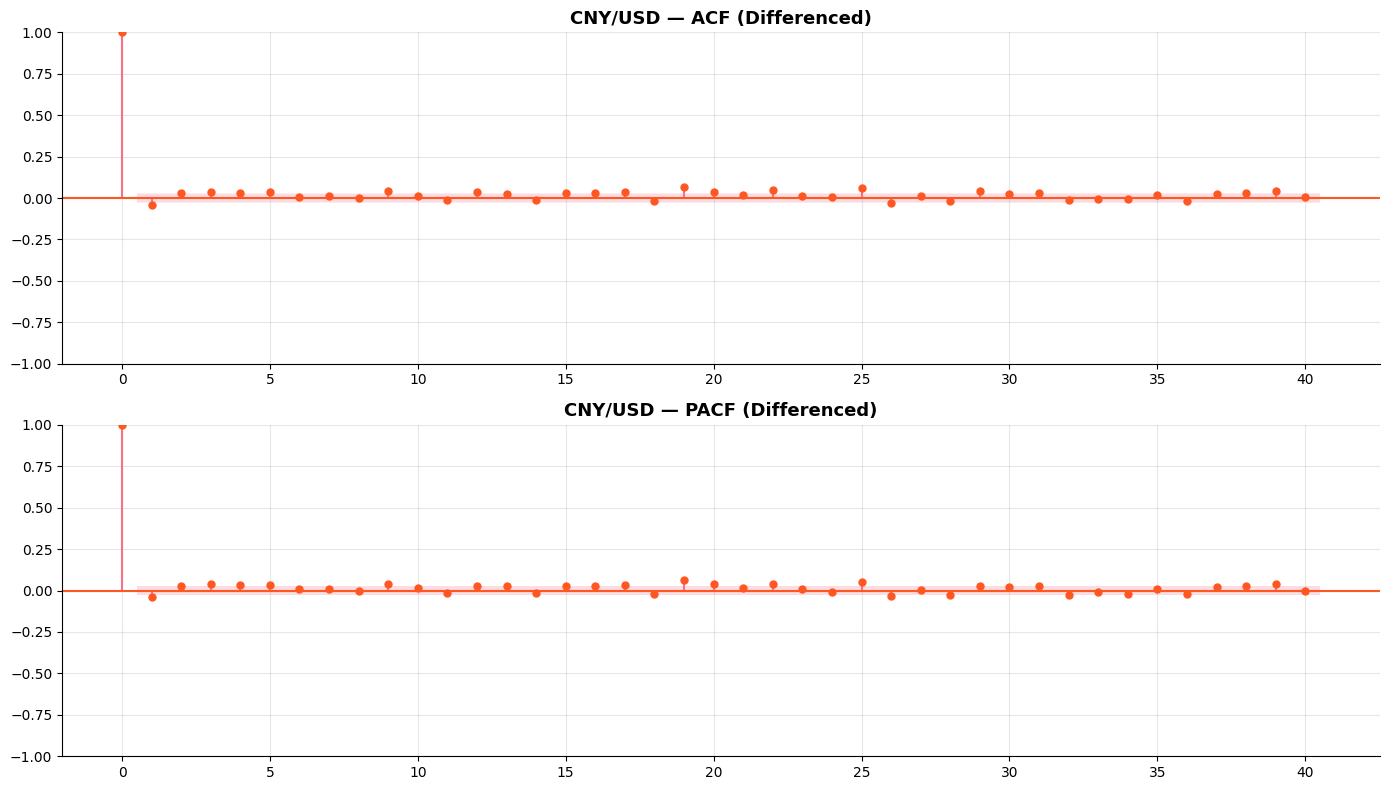

In [45]:
# ACF & PACF — CNY/USD (Differenced)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df["cny_diff"].dropna(), lags=40, ax=axes[0], color="#FF5722")
axes[0].set_title("CNY/USD — ACF (Differenced)", fontsize=13, fontweight="bold")

plot_pacf(df["cny_diff"].dropna(), lags=40, ax=axes[1], color="#FF5722")
axes[1].set_title("CNY/USD — PACF (Differenced)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("./reports/12_acf_pacf_cny.png", dpi=150, bbox_inches="tight")
plt.show()

## ACF & PACF Findings

Both SGD/USD and CNY/USD show identical behaviour after differencing — ACF and PACF 
drop immediately to zero after lag 0, with no significant correlations at any subsequent lag. 
This is the hallmark of a **random walk** process, a well-documented characteristic of 
foreign exchange markets.

| Currency | p (from PACF) | d (confirmed) | q (from ACF) | Starting ARIMA |
|---|---|---|---|---|
| SGD/USD | 0 | 1 | 0 | ARIMA(0,1,0) |
| CNY/USD | 0 | 1 | 0 | ARIMA(0,1,0) |

While ARIMA(0,1,0) serves as our baseline, we will systematically test higher-order 
combinations during modelling using **AIC/BIC scoring** to determine the optimal parameters.

---

## EDA Summary

| Finding | Detail |
|---|---|
| **Data Quality** | 198 SGD / 197 CNY hidden missing values (`ND`) — resolved via forward fill |
| **Long-term Trend** | Both currencies show clear non-stationary trends over 20 years |
| **Structural Break** | CNY shows a sharp break in 2005 when China removed the USD peg |
| **Volatility** | Clusters around 2008 GFC, 2011 EU debt crisis, 2018 US-China trade war |
| **Correlation** | SGD & CNY are 95.6% correlated — justifies VAR/VECM multivariate modelling |
| **Stationarity** | Both series are I(1) — first-order differencing confirms stationarity |
| **Random Walk** | ACF/PACF confirm both currencies behave as random walks after differencing |

---

## 7. Feature Engineering

Raw exchange rates alone are insufficient for machine learning models. We need to engineer 
meaningful features that capture the temporal structure, momentum, and volatility of the series.

We will create the following feature categories:

| Category | Features |
|---|---|
| **Lag Features** | Previous 1, 2, 3, 5, 10, 21 day rates — gives the model historical context |
| **Rolling Statistics** | 7, 21, 63 day rolling mean and standard deviation |
| **Momentum** | 7, 21 day rate of change — captures speed and direction of movement |
| **Calendar Features** | Day of week, month, quarter, year — captures seasonal patterns |
| **Cross-currency** | SGD as a feature for CNY and vice versa — captures the 95.6% correlation |

In [46]:
# Lag features — SGD
for lag in [1, 2, 3, 5, 10, 21]:
    df[f"sgd_lag_{lag}"] = df["sgd_usd"].shift(lag)

# Lag features — CNY
for lag in [1, 2, 3, 5, 10, 21]:
    df[f"cny_lag_{lag}"] = df["cny_usd"].shift(lag)

print("Lag features created ✅")
df.filter(like="lag").head(25)

Lag features created ✅


,sgd_lag_1,sgd_lag_2,sgd_lag_3,sgd_lag_5,sgd_lag_10,sgd_lag_21,cny_lag_1,cny_lag_2,cny_lag_3,cny_lag_5,cny_lag_10,cny_lag_21
date,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,1.656300,NaN,NaN,NaN,NaN,NaN,8.279800,NaN,NaN,NaN,NaN,NaN
2000-01-05,1.653500,1.656300,NaN,NaN,NaN,NaN,8.279900,8.279800,NaN,NaN,NaN,NaN
2000-01-06,1.656000,1.653500,1.656300,NaN,NaN,NaN,8.279800,8.279900,8.279800,NaN,NaN,NaN
2000-01-07,1.665500,1.656000,1.653500,NaN,NaN,NaN,8.279700,8.279800,8.279900,NaN,NaN,NaN
2000-01-10,1.662500,1.665500,1.656000,1.656300,NaN,NaN,8.279400,8.279700,8.279800,8.279800,NaN,NaN
2000-01-11,1.661800,1.662500,1.665500,1.653500,NaN,NaN,8.279400,8.279400,8.279700,8.279900,NaN,NaN
2000-01-12,1.669000,1.661800,1.662500,1.656000,NaN,NaN,8.279500,8.279400,8.279400,8.279800,NaN,NaN
2000-01-13,1.669000,1.669000,1.661800,1.665500,NaN,NaN,8.279600,8.279500,8.279400,8.279700,NaN,NaN


In [47]:
# Rolling mean and std — SGD
for window in [7, 21, 63]:
    df[f"sgd_roll_mean_{window}"] = df["sgd_usd"].rolling(window).mean()
    df[f"sgd_roll_std_{window}"]  = df["sgd_usd"].rolling(window).std()

# Rolling mean and std — CNY
for window in [7, 21, 63]:
    df[f"cny_roll_mean_{window}"] = df["cny_usd"].rolling(window).mean()
    df[f"cny_roll_std_{window}"]  = df["cny_usd"].rolling(window).std()

print("Rolling features created ✅")
df.filter(like="roll_mean").head(10)

Rolling features created ✅


,sgd_roll_mean,cny_roll_mean,sgd_roll_mean_7,sgd_roll_mean_21,sgd_roll_mean_63,cny_roll_mean_7,cny_roll_mean_21,cny_roll_mean_63
date,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,1.660657,NaN,NaN,8.279643,NaN,NaN
2000-01-12,NaN,NaN,1.662471,NaN,NaN,8.279614,NaN,NaN
2000-01-13,NaN,NaN,1.664829,NaN,NaN,8.279600,NaN,NaN


In [48]:
# Momentum — rate of change
for window in [7, 21]:
    df[f"sgd_roc_{window}"] = df["sgd_usd"].pct_change(window) * 100
    df[f"cny_roc_{window}"] = df["cny_usd"].pct_change(window) * 100

print("Momentum features created ✅")
df.filter(like="roc").head(25)

Momentum features created ✅


,sgd_roc_7,cny_roc_7,sgd_roc_21,cny_roc_21
date,,,,
2000-01-03,NaN,NaN,NaN,NaN
2000-01-04,NaN,NaN,NaN,NaN
2000-01-05,NaN,NaN,NaN,NaN
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.766769,-0.002416,NaN,NaN
2000-01-13,0.997883,-0.001208,NaN,NaN


In [49]:
# Calendar features
df["day_of_week"] = df.index.dayofweek
df["month"]       = df.index.month
df["quarter"]     = df.index.quarter
df["year"]        = df.index.year

print("Calendar features created ✅")
df[["day_of_week", "month", "quarter", "year"]].head(10)

Calendar features created ✅


,day_of_week,month,quarter,year
date,,,,
2000-01-03,0,1,1,2000
2000-01-04,1,1,1,2000
2000-01-05,2,1,1,2000
2000-01-06,3,1,1,2000
2000-01-07,4,1,1,2000
2000-01-10,0,1,1,2000
2000-01-11,1,1,1,2000
2000-01-12,2,1,1,2000
2000-01-13,3,1,1,2000


In [50]:
# Cross-currency features
df["sgd_cny_ratio"] = df["sgd_usd"] / df["cny_usd"]
df["sgd_cny_spread"] = df["sgd_usd"] - df["cny_usd"]

print("Cross-currency features created ✅")
df[["sgd_cny_ratio", "sgd_cny_spread"]].head(10)

Cross-currency features created ✅


,sgd_cny_ratio,sgd_cny_spread
date,,
2000-01-03,0.200041,-6.623500
2000-01-04,0.199700,-6.626400
2000-01-05,0.200005,-6.623800
2000-01-06,0.201155,-6.614200
2000-01-07,0.200800,-6.616900
2000-01-10,0.200715,-6.617600
2000-01-11,0.201582,-6.610500
2000-01-12,0.201580,-6.610600
2000-01-13,0.201696,-6.609800


In [51]:
# Full feature summary
print(f"Total features : {df.shape[1]}")
print(f"\nAll columns:")
for col in df.columns:
    print(f"   {col}")

Total features : 44

All columns:
   sgd_usd
   cny_usd
   sgd_roll_mean
   sgd_roll_std
   cny_roll_mean
   cny_roll_std
   sgd_returns
   cny_returns
   sgd_diff
   cny_diff
   sgd_lag_1
   sgd_lag_2
   sgd_lag_3
   sgd_lag_5
   sgd_lag_10
   sgd_lag_21
   cny_lag_1
   cny_lag_2
   cny_lag_3
   cny_lag_5
   cny_lag_10
   cny_lag_21
   sgd_roll_mean_7
   sgd_roll_std_7
   sgd_roll_mean_21
   sgd_roll_std_21
   sgd_roll_mean_63
   sgd_roll_std_63
   cny_roll_mean_7
   cny_roll_std_7
   cny_roll_mean_21
   cny_roll_std_21
   cny_roll_mean_63
   cny_roll_std_63
   sgd_roc_7
   cny_roc_7
   sgd_roc_21
   cny_roc_21
   day_of_week
   month
   quarter
   year
   sgd_cny_ratio
   sgd_cny_spread


In [52]:
# Drop NaN rows created by feature engineering
df_clean = df.dropna()

print(f"Original shape : {df.shape}")
print(f"Clean shape    : {df_clean.shape}")
print(f"Rows dropped   : {df.shape[0] - df_clean.shape[0]}")

Original shape : (5217, 44)
Clean shape    : (5155, 44)
Rows dropped   : 62


### Skewness Check

In [53]:
# Check skewness of target variables
print("── Skewness ────────────────────────────────")
print(f"SGD/USD : {df_clean['sgd_usd'].skew():.4f}")
print(f"CNY/USD : {df_clean['cny_usd'].skew():.4f}")

── Skewness ────────────────────────────────
SGD/USD : 0.4473
CNY/USD : 0.2782


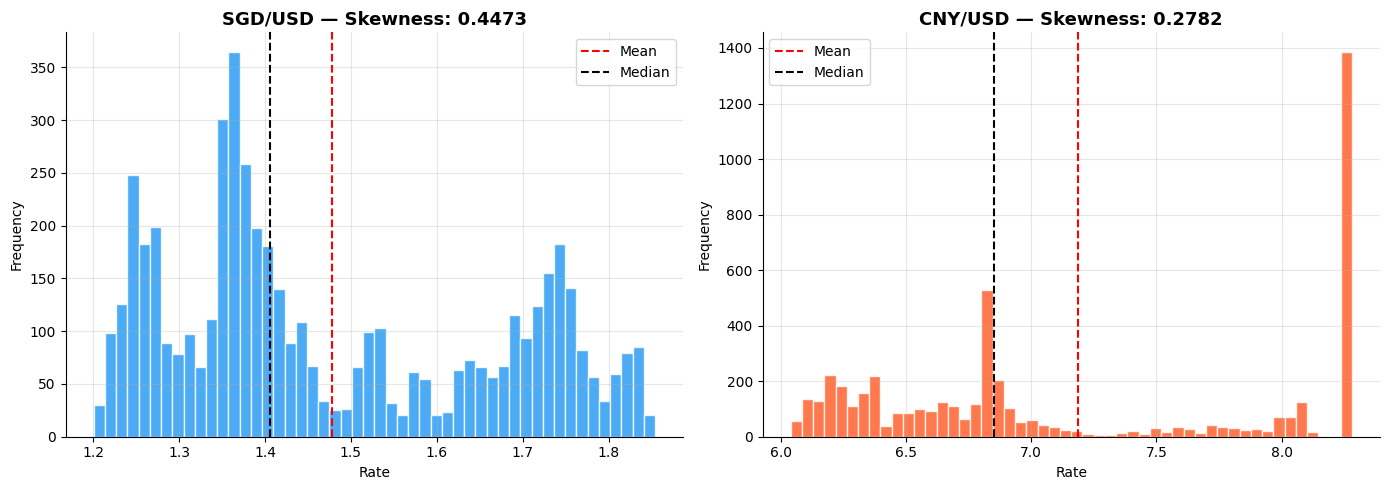

In [54]:
# Visualise skewness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean["sgd_usd"], bins=50, color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].axvline(df_clean["sgd_usd"].mean(), color="red", linestyle="--", linewidth=1.5, label="Mean")
axes[0].axvline(df_clean["sgd_usd"].median(), color="black", linestyle="--", linewidth=1.5, label="Median")
axes[0].set_title(f"SGD/USD — Skewness: {df_clean['sgd_usd'].skew():.4f}", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Rate")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(df_clean["cny_usd"], bins=50, color="#FF5722", edgecolor="white", alpha=0.8)
axes[1].axvline(df_clean["cny_usd"].mean(), color="red", linestyle="--", linewidth=1.5, label="Mean")
axes[1].axvline(df_clean["cny_usd"].median(), color="black", linestyle="--", linewidth=1.5, label="Median")
axes[1].set_title(f"CNY/USD — Skewness: {df_clean['cny_usd'].skew():.4f}", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Rate")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("./reports/13_skewness.png", dpi=150, bbox_inches="tight")
plt.show()

### Skewness Decision

Both target variables show **mild skewness** (SGD: 0.45, CNY: 0.28) — well within the 
acceptable range of ±0.5. No transformation is required for the following reasons:

- **Interpretability:** Predictions must remain in the original rate scale for business use
- **Real events:** Extreme values represent actual market events (2008 GFC, 2005 peg removal) 
  and must be preserved — a model blind to crises is dangerous for a bank
- **Scaling:** MinMaxScaler will be applied to features before ML models to handle 
  scale differences without distorting the time series structure

We proceed with the original scale.

## 8. Train/Test Split

In [55]:
# Train/Test split — 80/20 chronological
split_idx = int(len(df_clean) * 0.80)

train = df_clean.iloc[:split_idx]
test  = df_clean.iloc[split_idx:]

print(f"Train : {train.shape} | {train.index.min().date()} → {train.index.max().date()}")
print(f"Test  : {test.shape}  | {test.index.min().date()} → {test.index.max().date()}")

Train : (4124, 44) | 2000-03-29 → 2016-01-18
Test  : (1031, 44)  | 2016-01-19 → 2019-12-31


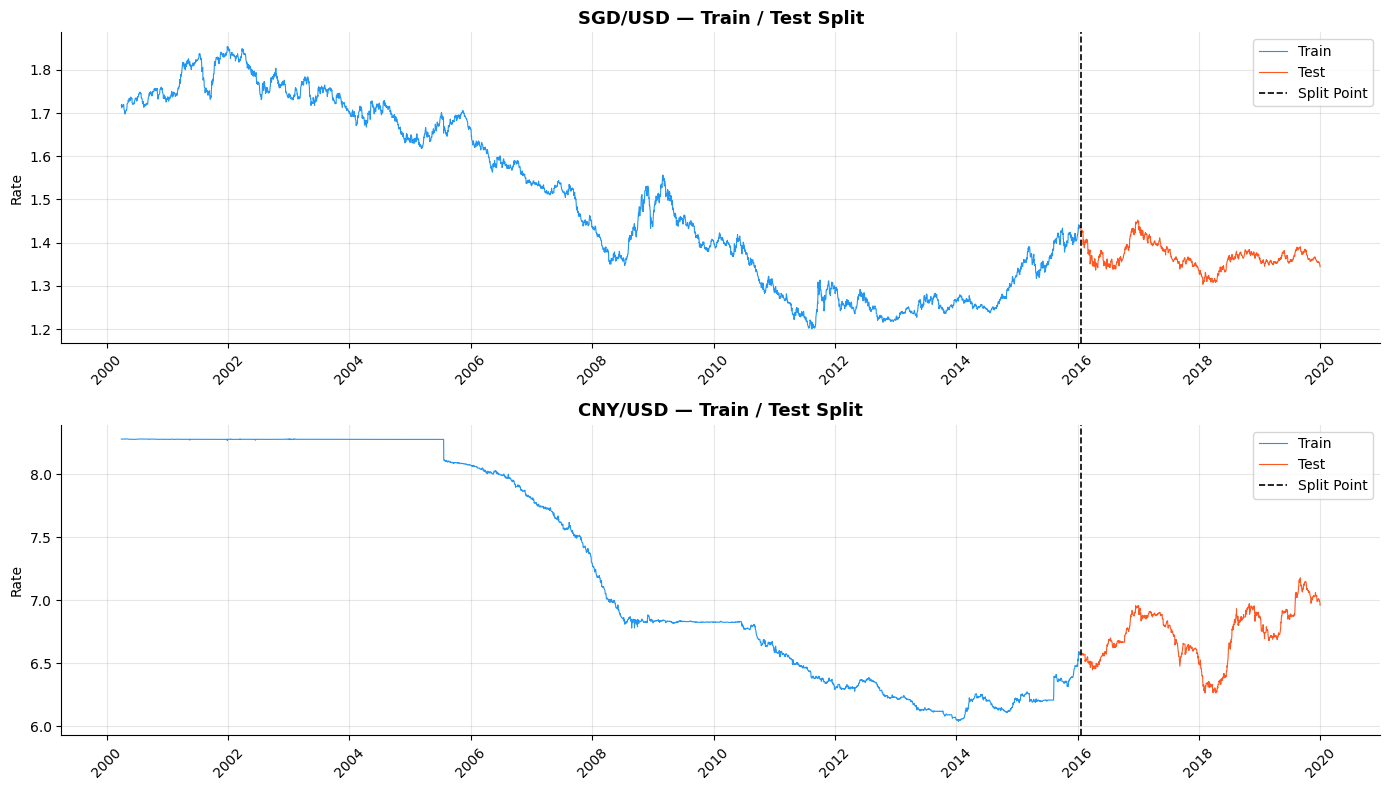

In [56]:
# Visualise train/test split
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train["sgd_usd"], color="#2196F3", linewidth=0.8, label="Train")
axes[0].plot(test["sgd_usd"], color="#FF5722", linewidth=0.8, label="Test")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1.2, label="Split Point")
axes[0].set_title("SGD/USD — Train / Test Split", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train["cny_usd"], color="#2196F3", linewidth=0.8, label="Train")
axes[1].plot(test["cny_usd"], color="#FF5722", linewidth=0.8, label="Test")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1.2, label="Split Point")
axes[1].set_title("CNY/USD — Train / Test Split", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/14_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

In [57]:
# Define features and targets
features = [col for col in df_clean.columns if col not in ["sgd_usd", "cny_usd", 
                                                             "sgd_diff", "cny_diff",
                                                             "sgd_returns", "cny_returns"]]

X_train_sgd = train[features]
y_train_sgd = train["sgd_usd"]

X_test_sgd  = test[features]
y_test_sgd  = test["sgd_usd"]

X_train_cny = train[features]
y_train_cny = train["cny_usd"]

X_test_cny  = test[features]
y_test_cny  = test["cny_usd"]

print(f"Features       : {len(features)}")
print(f"X_train shape  : {X_train_sgd.shape}")
print(f"X_test shape   : {X_test_sgd.shape}")
print(f"\nFeatures list:")
print(features)

Features       : 38
X_train shape  : (4124, 38)
X_test shape   : (1031, 38)

Features list:
['sgd_roll_mean', 'sgd_roll_std', 'cny_roll_mean', 'cny_roll_std', 'sgd_lag_1', 'sgd_lag_2', 'sgd_lag_3', 'sgd_lag_5', 'sgd_lag_10', 'sgd_lag_21', 'cny_lag_1', 'cny_lag_2', 'cny_lag_3', 'cny_lag_5', 'cny_lag_10', 'cny_lag_21', 'sgd_roll_mean_7', 'sgd_roll_std_7', 'sgd_roll_mean_21', 'sgd_roll_std_21', 'sgd_roll_mean_63', 'sgd_roll_std_63', 'cny_roll_mean_7', 'cny_roll_std_7', 'cny_roll_mean_21', 'cny_roll_std_21', 'cny_roll_mean_63', 'cny_roll_std_63', 'sgd_roc_7', 'cny_roc_7', 'sgd_roc_21', 'cny_roc_21', 'day_of_week', 'month', 'quarter', 'year', 'sgd_cny_ratio', 'sgd_cny_spread']


In [58]:
# Evaluation metrics function
def evaluate_model(y_true, y_pred, model_name):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2    = r2_score(y_true, y_pred)
    maxe  = max_error(y_true, y_pred)
    da    = np.mean(np.sign(np.diff(y_true.values)) == np.sign(np.diff(y_pred))) * 100

    print(f"── {model_name} ──────────────────────────────")
    print(f"RMSE               : {rmse:.6f}")
    print(f"MAE                : {mae:.6f}")
    print(f"MAPE               : {mape:.4f}%")
    print(f"R²                 : {r2:.6f}")
    print(f"Max Error          : {maxe:.6f}")
    print(f"Directional Acc.   : {da:.2f}%")

    return {"model": model_name, "RMSE": rmse, "MAE": mae, 
            "MAPE": mape, "R2": r2, "MaxError": maxe, "DA": da}

print("✅ Evaluation function ready")

✅ Evaluation function ready


## 9. Modelling

We follow a structured progression from simple baseline models to increasingly sophisticated 
approaches. Each model is evaluated using the same metrics and test set for fair comparison.

| Stage | Models |
|---|---|
| **Baseline** | Naïve Random Walk |
| **Statistical** | Holt-Winters, ARIMA, SARIMA, SARIMAX, VAR, VECM |
| **Forecasting Frameworks** | Facebook Prophet |
| **Machine Learning** | Decision Tree, Random Forest, SVR, XGBoost, LightGBM |
| **Deep Learning** | LSTM, GRU, Transformer |
| **Hybrid & Ensemble** | ARIMA-LSTM Hybrid, Ensemble Stacking |

### 9.1 Baseline — Naïve Random Walk

The naïve model predicts that tomorrow's rate will equal today's rate. 
This is the simplest possible forecast and serves as the minimum benchmark 
every subsequent model must beat. In efficient markets, this is surprisingly 
difficult to outperform.

In [59]:
# Naïve forecast — shift by 1 day (today's value = tomorrow's prediction)
naive_pred_sgd = y_test_sgd.shift(1).dropna()
naive_pred_cny = y_test_cny.shift(1).dropna()

# Align true values
naive_true_sgd = y_test_sgd.iloc[1:]
naive_true_cny = y_test_cny.iloc[1:]

print(f"Naive predictions shape : {naive_pred_sgd.shape}")

Naive predictions shape : (1030,)


In [60]:
# Naïve — in-sample fit on training data
naive_train_pred_sgd = y_train_sgd.shift(1).dropna()
naive_train_true_sgd = y_train_sgd.iloc[1:]

naive_train_pred_cny = y_train_cny.shift(1).dropna()
naive_train_true_cny = y_train_cny.iloc[1:]

print("── In-Sample Evaluation ────────────────────────────────")
naive_train_sgd_metrics = evaluate_model(naive_train_true_sgd, naive_train_pred_sgd, "Naïve Train — SGD/USD")
print()
naive_train_cny_metrics = evaluate_model(naive_train_true_cny, naive_train_pred_cny, "Naïve Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── Naïve Train — SGD/USD ──────────────────────────────
RMSE               : 0.004834
MAE                : 0.003444
MAPE               : 0.2318%
R²                 : 0.999422
Max Error          : 0.035500
Directional Acc.   : 45.05%

── Naïve Train — CNY/USD ──────────────────────────────
RMSE               : 0.007006
MAE                : 0.003143
MAPE               : 0.0463%
R²                 : 0.999935
Max Error          : 0.165400
Directional Acc.   : 42.29%


In [61]:
# Evaluate Naive model — SGD
naive_sgd_metrics = evaluate_model(naive_true_sgd, naive_pred_sgd, "Naïve — SGD/USD")

── Naïve — SGD/USD ──────────────────────────────
RMSE               : 0.004057
MAE                : 0.002815
MAPE               : 0.2055%
R²                 : 0.978431
Max Error          : 0.032600
Directional Acc.   : 46.74%


In [62]:
# Evaluate Naive model — CNY
naive_cny_metrics = evaluate_model(naive_true_cny, naive_pred_cny, "Naïve — CNY/USD")

── Naïve — CNY/USD ──────────────────────────────
RMSE               : 0.016075
MAE                : 0.010733
MAPE               : 0.1597%
R²                 : 0.994185
Max Error          : 0.109400
Directional Acc.   : 43.15%


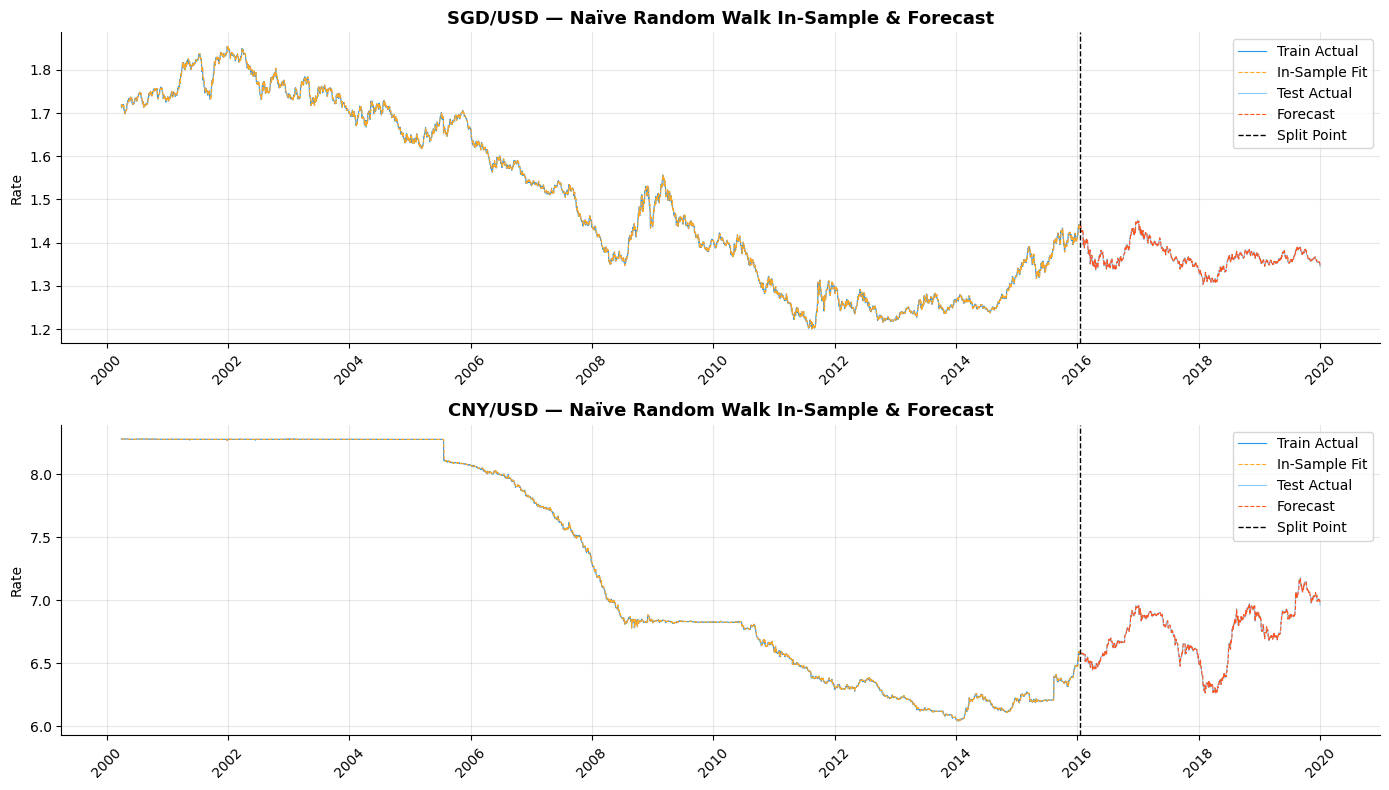

In [63]:
# Plot Naïve — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(naive_train_true_sgd.index, naive_train_true_sgd, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(naive_train_pred_sgd.index, naive_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(naive_true_sgd.index, naive_true_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(naive_pred_sgd.index, naive_pred_sgd, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — Naïve Random Walk In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(naive_train_true_cny.index, naive_train_true_cny, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(naive_train_pred_cny.index, naive_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(naive_true_cny.index, naive_true_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(naive_pred_cny.index, naive_pred_cny, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — Naïve Random Walk In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/15_naive_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### Naïve Baseline — Results

The naïve model tracks the actual rate almost perfectly visually — expected since it simply 
shifts by one day. However the metrics reveal its key weakness:

| Metric | SGD Naïve | CNY Naïve |
|---|---|---|
| RMSE | 0.004057 | 0.016075 |
| MAE | 0.002815 | 0.010733 |
| MAPE | 0.2055% | 0.1597% |
| R² | 0.9784 | 0.9942 |
| Directional Acc. | 46.74% | 43.15% |

**Key finding:** Directional accuracy is below 50% for both currencies — the naïve model 
cannot reliably predict whether the rate will go up or down the next day. This is the 
critical weakness all subsequent models must improve upon. These metrics serve as our 
**minimum benchmark**.

### 9.2 Holt-Winters (Exponential Smoothing)

Holt-Winters extends simple exponential smoothing by adding trend and seasonality components.
It assigns exponentially decreasing weights to past observations — recent values matter more
than older ones. Three smoothing parameters control the model:

- **Alpha (α):** controls the level (overall value)
- **Beta (β):** controls the trend component
- **Gamma (γ):** controls the seasonal component

In [64]:
# Fit Holt-Winters — SGD/USD
hw_sgd = ExponentialSmoothing(
    train["sgd_usd"],
    trend="add",
    seasonal="add",
    seasonal_periods=252
).fit()

print("✅ Holt-Winters SGD fitted")

✅ Holt-Winters SGD fitted


/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [65]:
# Holt-Winters SGD — key model parameters
print("── Holt-Winters SGD/USD — Model Parameters ─────────────")
print(f"AIC                  : {hw_sgd.aic:.3f}")
print(f"BIC                  : {hw_sgd.bic:.3f}")
print(f"SSE                  : {hw_sgd.sse:.3f}")
print(f"Smoothing Level (α)  : {hw_sgd.params['smoothing_level']:.6f}")
print(f"Smoothing Trend (β)  : {hw_sgd.params['smoothing_trend']:.6f}")
print(f"Smoothing Season (γ) : {hw_sgd.params['smoothing_seasonal']:.6f}")
print(f"Initial Level        : {hw_sgd.params['initial_level']:.6f}")
print(f"Initial Trend        : {hw_sgd.params['initial_trend']:.6f}")

── Holt-Winters SGD/USD — Model Parameters ─────────────
AIC                  : -43720.358
BIC                  : -42101.266
SSE                  : 0.091
Smoothing Level (α)  : 1.000000
Smoothing Trend (β)  : 0.000000
Smoothing Season (γ) : 0.000000
Initial Level        : 1.720405
Initial Trend        : -0.000051


In [66]:
# Fit Holt-Winters — CNY/USD
hw_cny = ExponentialSmoothing(
    train["cny_usd"],
    trend="add",
    seasonal="add",
    seasonal_periods=252
).fit()

print("✅ Holt-Winters CNY fitted")

✅ Holt-Winters CNY fitted


/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [67]:
# Holt-Winters CNY — key model parameters
print("── Holt-Winters CNY/USD — Model Parameters ─────────────")
print(f"AIC                  : {hw_cny.aic:.3f}")
print(f"BIC                  : {hw_cny.bic:.3f}")
print(f"SSE                  : {hw_cny.sse:.3f}")
print(f"Smoothing Level (α)  : {hw_cny.params['smoothing_level']:.6f}")
print(f"Smoothing Trend (β)  : {hw_cny.params['smoothing_trend']:.6f}")
print(f"Smoothing Season (γ) : {hw_cny.params['smoothing_seasonal']:.6f}")
print(f"Initial Level        : {hw_cny.params['initial_level']:.6f}")
print(f"Initial Trend        : {hw_cny.params['initial_trend']:.6f}")

── Holt-Winters CNY/USD — Model Parameters ─────────────
AIC                  : -40728.459
BIC                  : -39109.367
SSE                  : 0.187
Smoothing Level (α)  : 0.929473
Smoothing Trend (β)  : 0.009185
Smoothing Season (γ) : 0.000000
Initial Level        : 8.274545
Initial Trend        : 0.000055


In [68]:
# Holt-Winters — in-sample evaluation (training data)
hw_train_pred_sgd = hw_sgd.fittedvalues
hw_train_pred_cny = hw_cny.fittedvalues

print("── In-Sample Evaluation ────────────────────────────────")
hw_train_sgd_metrics = evaluate_model(y_train_sgd, hw_train_pred_sgd, "Holt-Winters Train — SGD/USD")
print()
hw_train_cny_metrics = evaluate_model(y_train_cny, hw_train_pred_cny, "Holt-Winters Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── Holt-Winters Train — SGD/USD ──────────────────────────────
RMSE               : 0.004688
MAE                : 0.003408
MAPE               : 0.2294%
R²                 : 0.999456
Max Error          : 0.034094
Directional Acc.   : 49.41%

── Holt-Winters Train — CNY/USD ──────────────────────────────
RMSE               : 0.006738
MAE                : 0.003527
MAPE               : 0.0511%
R²                 : 0.999940
Max Error          : 0.154392
Directional Acc.   : 39.44%


In [69]:
# Holt-Winters — out-of-sample predictions SGD
hw_sgd_pred = hw_sgd.forecast(len(test))
hw_sgd_pred.index = test.index

print(f"SGD predictions shape : {hw_sgd_pred.shape}")

SGD predictions shape : (1031,)


In [70]:
# Holt-Winters — evaluate out-of-sample SGD
hw_sgd_metrics = evaluate_model(y_test_sgd, hw_sgd_pred, "Holt-Winters — SGD/USD")

── Holt-Winters — SGD/USD ──────────────────────────────
RMSE               : 0.053092
MAE                : 0.046069
MAPE               : 3.4003%
R²                 : -2.675598
Max Error          : 0.107826
Directional Acc.   : 48.93%


In [71]:
# Holt-Winters — out-of-sample predictions CNY
hw_cny_pred = hw_cny.forecast(len(test))
hw_cny_pred.index = test.index

print(f"CNY predictions shape : {hw_cny_pred.shape}")

CNY predictions shape : (1031,)


In [72]:
# Holt-Winters — evaluate out-of-sample CNY
hw_cny_metrics = evaluate_model(y_test_cny, hw_cny_pred, "Holt-Winters — CNY/USD")

── Holt-Winters — CNY/USD ──────────────────────────────
RMSE               : 1.113274
MAE                : 0.951358
MAPE               : 14.1180%
R²                 : -26.902272
Max Error          : 1.834709
Directional Acc.   : 45.24%


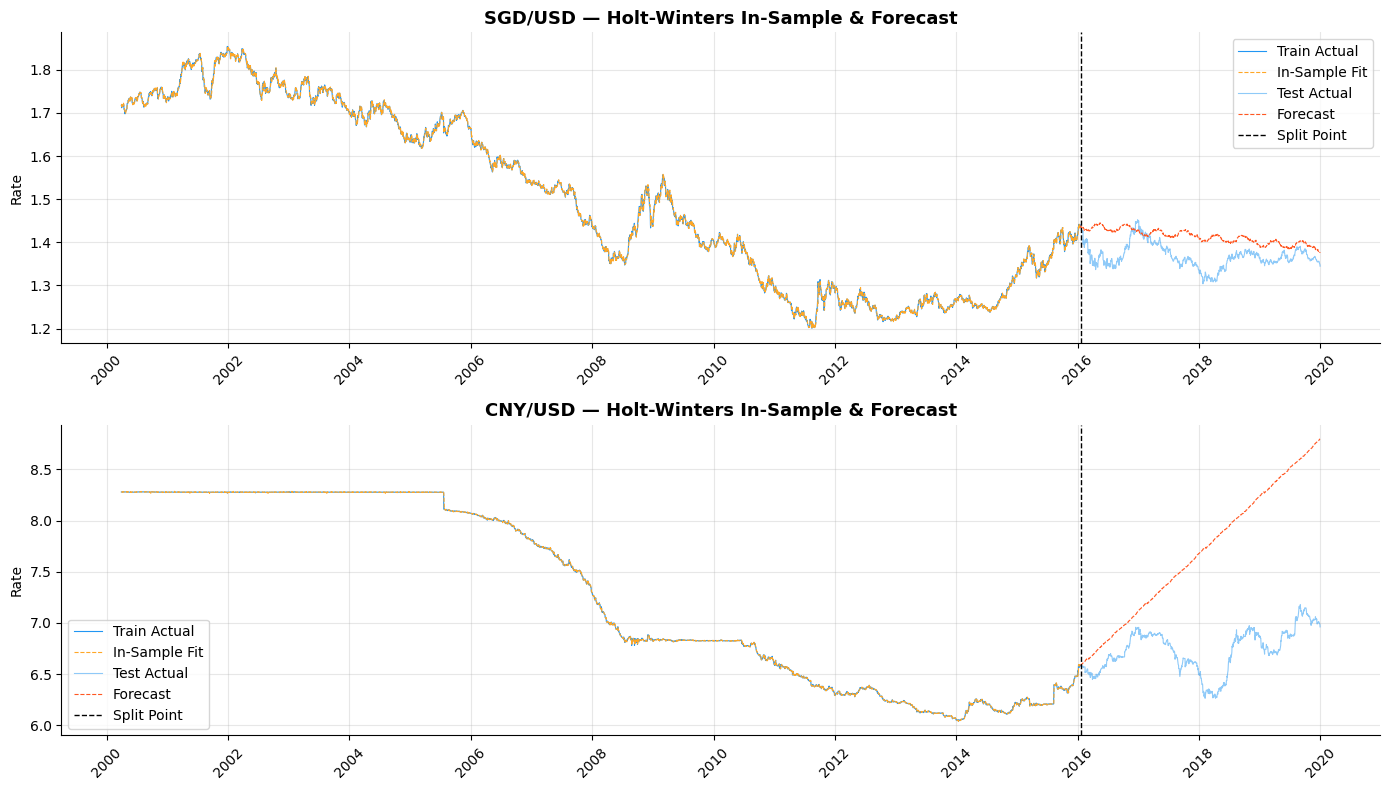

In [73]:
# Plot Holt-Winters — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train["sgd_usd"].index, train["sgd_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(hw_train_pred_sgd.index, hw_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(y_test_sgd.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(hw_sgd_pred.index, hw_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — Holt-Winters In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train["cny_usd"].index, train["cny_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(hw_train_pred_cny.index, hw_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(y_test_cny.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(hw_cny_pred.index, hw_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — Holt-Winters In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/16_holtwinters_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### Holt-Winters — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.004688 | 0.053092 | 0.006738 | 1.113274 |
| MAE | 0.003408 | 0.046069 | 0.003527 | 0.951358 |
| MAPE | 0.2294% | 3.4003% | 0.0511% | 14.1180% |
| R² | 0.9995 | -2.6756 | 0.9999 | -26.9023 |
| Max Error | 0.034094 | 0.107826 | 0.154392 | 1.834709 |
| Directional Acc. | 49.41% | 48.93% | 39.44% | 45.24% |

**Key findings:**
- Excellent in-sample fit (R² > 0.999) but catastrophic out-of-sample performance
- SGD forecast flattens — model learned the downward trend but rate stabilised post-2016
- CNY forecast shoots upward toward 8.5+ — the peg period dominates training and 
  creates a false upward trend signal
- Both models perform **worse than the naïve baseline**
- Holt-Winters is **not suitable** for currencies with structural breaks

### 9.3 ARIMA

ARIMA (AutoRegressive Integrated Moving Average) is a classical statistical model for 
time series forecasting. It combines three components:

- **AR(p):** uses past values to predict future values
- **I(d):** differencing to achieve stationarity — confirmed d=1 from our tests
- **MA(q):** uses past forecast errors to correct predictions

From our ACF/PACF analysis, the baseline is **ARIMA(0,1,0)**. We will also use 
**AIC/BIC scoring** to search for a better combination of p and q values.

In [74]:
# ARIMA order selection — SGD using AIC
from itertools import product

p_values = range(0, 4)
q_values = range(0, 4)
d = 1

best_aic_sgd = np.inf
best_order_sgd = None

for p, q in product(p_values, q_values):
    try:
        model = ARIMA(train["sgd_usd"], order=(p, d, q))
        result = model.fit()
        if result.aic < best_aic_sgd:
            best_aic_sgd = result.aic
            best_order_sgd = (p, d, q)
    except:
        continue

print(f"Best ARIMA order for SGD : {best_order_sgd}")
print(f"Best AIC                 : {best_aic_sgd:.3f}")

/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge.

Best ARIMA order for SGD : (0, 1, 0)
Best AIC                 : -32266.593


In [75]:
# ARIMA order selection — CNY using AIC
best_aic_cny = np.inf
best_order_cny = None

for p, q in product(p_values, q_values):
    try:
        model = ARIMA(train["cny_usd"], order=(p, d, q))
        result = model.fit()
        if result.aic < best_aic_cny:
            best_aic_cny = result.aic
            best_order_cny = (p, d, q)
    except:
        continue

print(f"Best ARIMA order for CNY : {best_order_cny}")
print(f"Best AIC                 : {best_aic_cny:.3f}")

/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge.

Best ARIMA order for CNY : (3, 1, 2)
Best AIC                 : -29266.012


In [76]:
# Fit ARIMA — SGD with best order
arima_sgd = ARIMA(train["sgd_usd"], order=best_order_sgd).fit()
print(f"✅ ARIMA{best_order_sgd} fitted for SGD")

✅ ARIMA(0, 1, 0) fitted for SGD


In [77]:
# ARIMA SGD — model summary
print(arima_sgd.summary())

                               SARIMAX Results                                
Dep. Variable:                sgd_usd   No. Observations:                 4124
Model:                 ARIMA(0, 1, 0)   Log Likelihood               16134.296
Date:                Sat, 07 Mar 2026   AIC                         -32266.593
Time:                        00:27:20   BIC                         -32260.268
Sample:                    03-29-2000   HQIC                        -32264.354
                         - 01-18-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2.336e-05    2.9e-07     80.569      0.000    2.28e-05    2.39e-05
Ljung-Box (L1) (Q):                   1.77   Jarque-Bera (JB):              3173.02
Prob(Q):                              0.18   Pr

In [78]:
# Fit ARIMA — CNY with best order
arima_cny = ARIMA(train["cny_usd"], order=best_order_cny).fit()
print(f"✅ ARIMA{best_order_cny} fitted for CNY")

✅ ARIMA(3, 1, 2) fitted for CNY


/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [79]:
# ARIMA CNY — model summary
print(arima_cny.summary())

                               SARIMAX Results                                
Dep. Variable:                cny_usd   No. Observations:                 4124
Model:                 ARIMA(3, 1, 2)   Log Likelihood               14639.006
Date:                Sat, 07 Mar 2026   AIC                         -29266.012
Time:                        00:27:21   BIC                         -29228.066
Sample:                    03-29-2000   HQIC                        -29252.581
                         - 01-18-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1611      0.063      2.549      0.011       0.037       0.285
ar.L2          0.6082      0.066      9.225      0.000       0.479       0.737
ar.L3          0.1190      0.008     14.688      0.0

In [80]:
# ARIMA — in-sample evaluation
arima_train_pred_sgd = arima_sgd.fittedvalues
arima_train_pred_cny = arima_cny.fittedvalues

print("── In-Sample Evaluation ────────────────────────────────")
arima_train_sgd_metrics = evaluate_model(train["sgd_usd"], arima_train_pred_sgd, "ARIMA Train — SGD/USD")
print()
arima_train_cny_metrics = evaluate_model(train["cny_usd"], arima_train_pred_cny, "ARIMA Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── ARIMA Train — SGD/USD ──────────────────────────────
RMSE               : 0.027167
MAE                : 0.003860
MAPE               : 0.2560%
R²                 : 0.981740
Max Error          : 1.716800
Directional Acc.   : 45.06%

── ARIMA Train — CNY/USD ──────────────────────────────
RMSE               : 0.129105
MAE                : 0.005170
MAPE               : 0.0709%
R²                 : 0.977978
Max Error          : 8.278900
Directional Acc.   : 37.06%


In [81]:
# ARIMA — out-of-sample forecast SGD
arima_sgd_pred = arima_sgd.forecast(steps=len(test))
arima_sgd_pred.index = test.index

print(f"SGD forecast shape : {arima_sgd_pred.shape}")
arima_sgd_pred.head()

SGD forecast shape : (1031,)


date
2016-01-19   1.440300
2016-01-20   1.440300
2016-01-21   1.440300
2016-01-22   1.440300
2016-01-25   1.440300
Name: predicted_mean, dtype: float64

In [82]:
# ARIMA — out-of-sample forecast CNY
arima_cny_pred = arima_cny.forecast(steps=len(test))
arima_cny_pred.index = test.index

print(f"CNY forecast shape : {arima_cny_pred.shape}")
arima_cny_pred.head()

CNY forecast shape : (1031,)


date
2016-01-19   6.587970
2016-01-20   6.588332
2016-01-21   6.590805
2016-01-22   6.591896
2016-01-25   6.593618
Name: predicted_mean, dtype: float64

In [83]:
# ARIMA — evaluate out-of-sample SGD
arima_sgd_metrics = evaluate_model(y_test_sgd, arima_sgd_pred, "ARIMA — SGD/USD")

── ARIMA — SGD/USD ──────────────────────────────
RMSE               : 0.077579
MAE                : 0.072655
MAPE               : 5.3537%
R²                 : -6.848131
Max Error          : 0.136600
Directional Acc.   : 4.95%


In [84]:
# ARIMA — evaluate out-of-sample CNY
arima_cny_metrics = evaluate_model(y_test_cny, arima_cny_pred, "ARIMA — CNY/USD")

── ARIMA — CNY/USD ──────────────────────────────
RMSE               : 0.240010
MAE                : 0.200973
MAPE               : 2.9567%
R²                 : -0.296857
Max Error          : 0.561546
Directional Acc.   : 26.60%


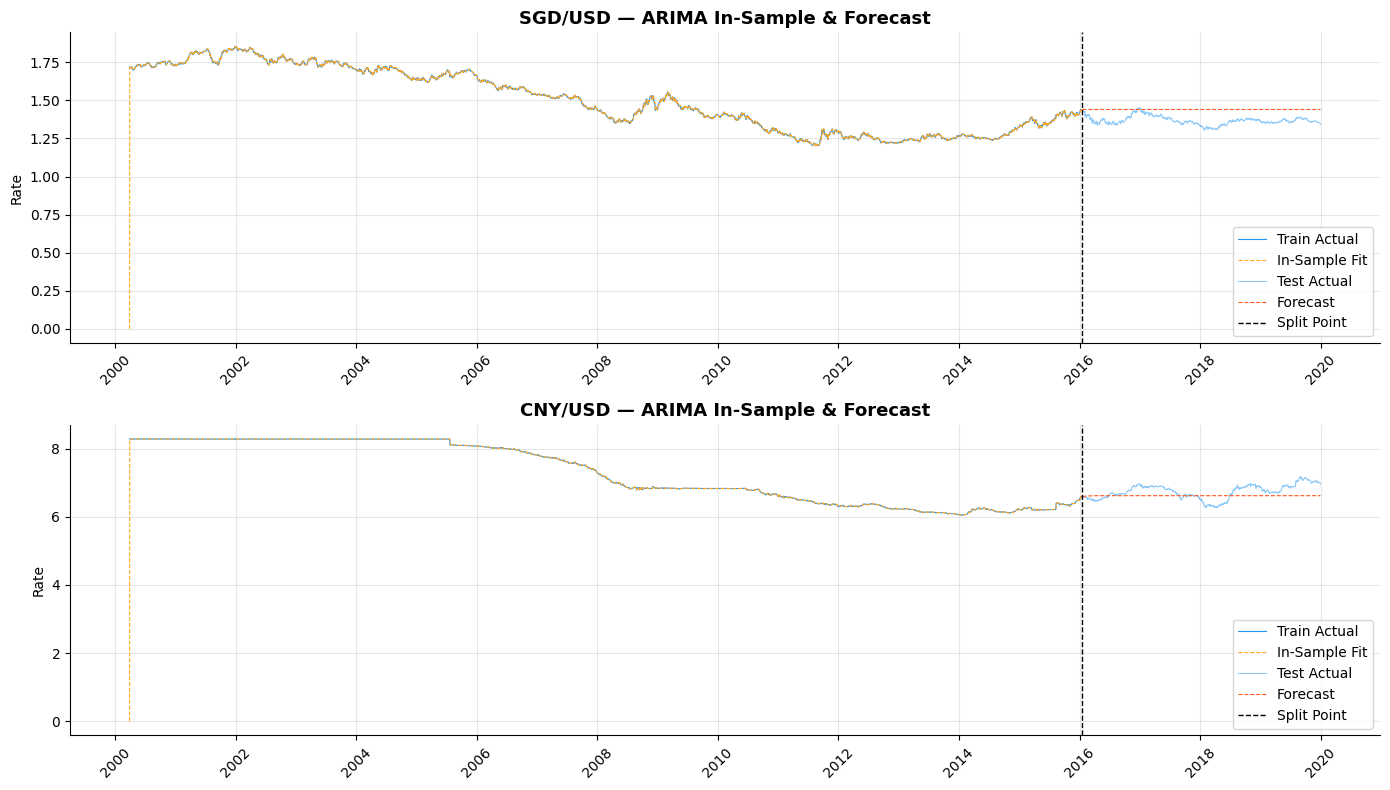

In [85]:
# Plot ARIMA — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train["sgd_usd"].index, train["sgd_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(arima_train_pred_sgd.index, arima_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(y_test_sgd.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(arima_sgd_pred.index, arima_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — ARIMA In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train["cny_usd"].index, train["cny_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(arima_train_pred_cny.index, arima_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(y_test_cny.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(arima_cny_pred.index, arima_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — ARIMA In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/17_arima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### ARIMA — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.027167 | 0.077579 | 0.129105 | 0.240010 |
| MAE | 0.003860 | 0.072655 | 0.005170 | 0.200973 |
| MAPE | 0.2560% | 5.3537% | 0.0709% | 2.9567% |
| R² | 0.9817 | -6.8481 | 0.9780 | -0.2969 |
| Max Error | 1.7168 | 0.1366 | 8.2789 | 0.5615 |
| Directional Acc. | 45.06% | 4.95% | 37.06% | 26.60% |

**Key findings:**
- **SGD ARIMA(0,1,0):** Flat forecast — model predicts the last known value indefinitely.
  Directional accuracy of 4.95% is worse than random — the model is actively misleading
- **CNY ARIMA(3,1,2):** Slight momentum captured but quickly flattens. Better than SGD 
  but still poor out-of-sample performance
- Both models perform **worse than the naïve baseline**
- ARIMA's limitation is clear — it cannot adapt once forecasting begins without new data

### 9.4 SARIMA

SARIMA (Seasonal ARIMA) extends ARIMA by adding seasonal components. It has the form 
**ARIMA(p,d,q)(P,D,Q)[s]** where:

- **(p,d,q):** non-seasonal AR, differencing, and MA terms — same as ARIMA
- **(P,D,Q):** seasonal AR, differencing, and MA terms
- **[s]:** seasonal period — for daily financial data we use s=252 (trading days per year)

SARIMA is useful when the series has repeating seasonal patterns. Our seasonal 
decomposition showed weak but present seasonality in both currencies.

In [86]:
# Fit SARIMA — SGD
# order=(0,1,0) from ACF/PACF + seasonal=(1,0,1,5) for weekly pattern
sarima_sgd = SARIMAX(train["sgd_usd"],
                     order=(0, 1, 0),
                     seasonal_order=(1, 0, 1, 5)).fit(disp=False)

print("✅ SARIMA fitted for SGD")

✅ SARIMA fitted for SGD


In [87]:
# SARIMA SGD — key model parameters
print(sarima_sgd.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             sgd_usd   No. Observations:                 4124
Model:             SARIMAX(0, 1, 0)x(1, 0, [1], 5)   Log Likelihood               16135.413
Date:                             Sat, 07 Mar 2026   AIC                         -32264.827
Time:                                     00:27:22   BIC                         -32245.854
Sample:                                 03-29-2000   HQIC                        -32258.111
                                      - 01-18-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L5       -0.1662      0.496     -0.335      0.738      -1.139       0.807
ma.S.L5        0.1910      

In [88]:
# Fit SARIMA — CNY
sarima_cny = SARIMAX(train["cny_usd"],
                     order=(3, 1, 2),
                     seasonal_order=(1, 0, 1, 5)).fit(disp=False)

print("✅ SARIMA fitted for CNY")

✅ SARIMA fitted for CNY


/Users/akinsholaakinade/Desktop/currency-forecasting/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [89]:
# SARIMA CNY — model summary
print(sarima_cny.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             cny_usd   No. Observations:                 4124
Model:             SARIMAX(3, 1, 2)x(1, 0, [1], 5)   Log Likelihood               14641.593
Date:                             Sat, 07 Mar 2026   AIC                         -29267.187
Time:                                     00:27:25   BIC                         -29216.592
Sample:                                 03-29-2000   HQIC                        -29249.280
                                      - 01-18-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1268      0.059      2.153      0.031       0.011       0.242
ar.L2          0.6636      

In [90]:
# SARIMA — in-sample evaluation
sarima_train_pred_sgd = sarima_sgd.fittedvalues
sarima_train_pred_cny = sarima_cny.fittedvalues

print("── In-Sample Evaluation ────────────────────────────────")
sarima_train_sgd_metrics = evaluate_model(train["sgd_usd"], sarima_train_pred_sgd, "SARIMA Train — SGD/USD")
print()
sarima_train_cny_metrics = evaluate_model(train["cny_usd"], sarima_train_pred_cny, "SARIMA Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── SARIMA Train — SGD/USD ──────────────────────────────
RMSE               : 0.027167
MAE                : 0.003862
MAPE               : 0.2562%
R²                 : 0.981740
Max Error          : 1.716800
Directional Acc.   : 47.54%

── SARIMA Train — CNY/USD ──────────────────────────────
RMSE               : 0.129105
MAE                : 0.005170
MAPE               : 0.0709%
R²                 : 0.977978
Max Error          : 8.278900
Directional Acc.   : 37.06%


In [91]:
# SARIMA — out-of-sample forecast SGD
sarima_sgd_pred = sarima_sgd.forecast(steps=len(test))
sarima_sgd_pred.index = test.index

print(f"SGD forecast shape : {sarima_sgd_pred.shape}")

SGD forecast shape : (1031,)


In [92]:
# SARIMA — out-of-sample forecast CNY
sarima_cny_pred = sarima_cny.forecast(steps=len(test))
sarima_cny_pred.index = test.index

print(f"CNY forecast shape : {sarima_cny_pred.shape}")

CNY forecast shape : (1031,)


In [93]:
# SARIMA — evaluate out-of-sample SGD
sarima_sgd_metrics = evaluate_model(y_test_sgd, sarima_sgd_pred, "SARIMA — SGD/USD")

── SARIMA — SGD/USD ──────────────────────────────
RMSE               : 0.077661
MAE                : 0.072740
MAPE               : 5.3599%
R²                 : -6.864618
Max Error          : 0.136687
Directional Acc.   : 8.35%


In [94]:
# SARIMA — evaluate out-of-sample CNY
sarima_cny_metrics = evaluate_model(y_test_cny, sarima_cny_pred, "SARIMA — CNY/USD")

── SARIMA — CNY/USD ──────────────────────────────
RMSE               : 0.234867
MAE                : 0.196196
MAPE               : 2.8893%
R²                 : -0.241877
Max Error          : 0.550666
Directional Acc.   : 30.00%


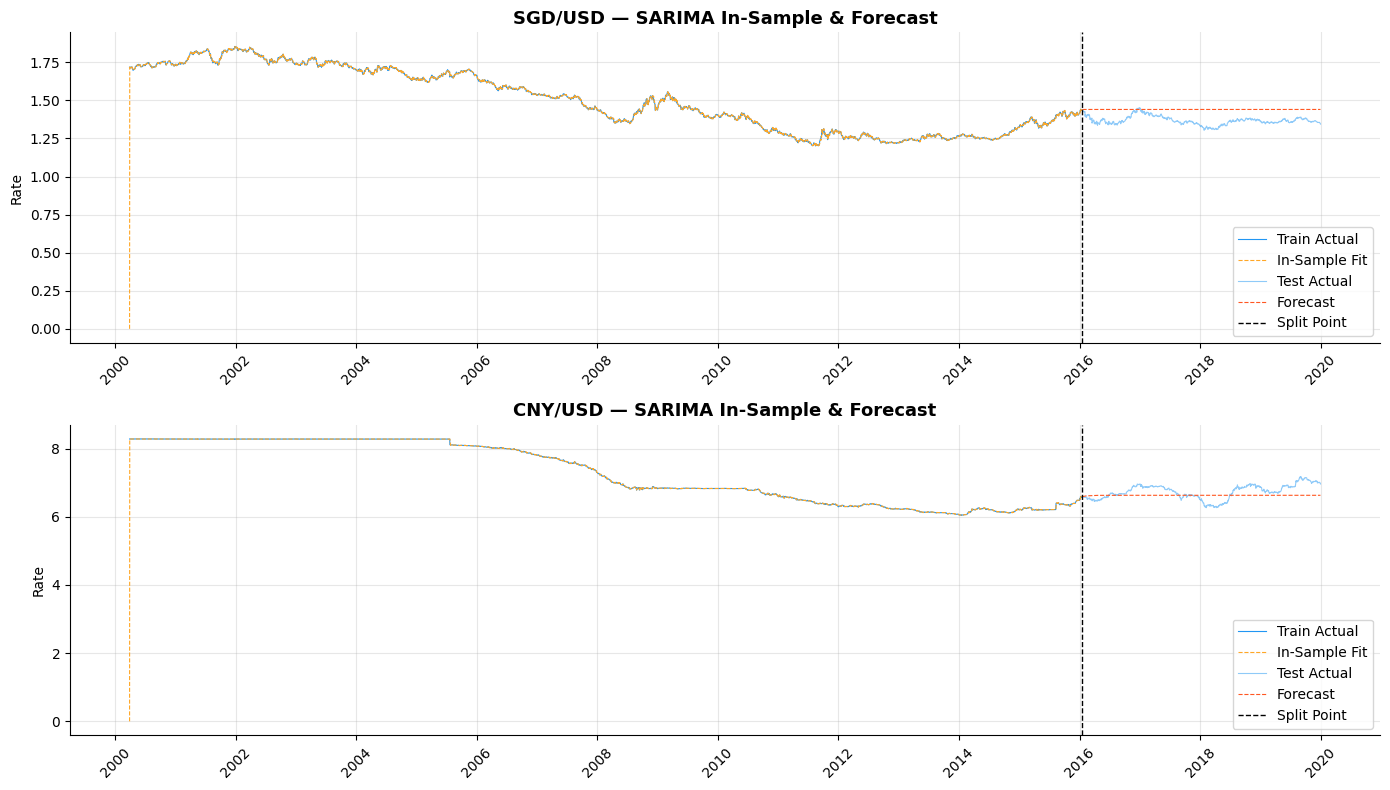

In [95]:
# Plot SARIMA — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train["sgd_usd"].index, train["sgd_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(sarima_train_pred_sgd.index, sarima_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(y_test_sgd.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(sarima_sgd_pred.index, sarima_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — SARIMA In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train["cny_usd"].index, train["cny_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(sarima_train_pred_cny.index, sarima_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(y_test_cny.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(sarima_cny_pred.index, sarima_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — SARIMA In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/18_sarima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### SARIMA — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.027167 | 0.077661 | 0.129105 | 0.234867 |
| MAE | 0.003862 | 0.072740 | 0.005170 | 0.196196 |
| MAPE | 0.2562% | 5.3599% | 0.0709% | 2.8893% |
| R² | 0.9817 | -6.8646 | 0.9780 | -0.2419 |
| Max Error | 1.7168 | 0.136687 | 8.2789 | 0.550666 |
| Directional Acc. | 47.54% | 8.35% | 37.06% | 30.00% |

**Key findings:**
- SARIMA performs almost identically to ARIMA for both currencies
- Seasonal AR and MA terms are statistically insignificant (p > 0.05) for both currencies
- SARIMA AIC is marginally worse than ARIMA for SGD — adding seasonal terms hurt the model
- **Conclusion:** Weekly seasonality does not exist in these forex series — 
  SARIMA offers no advantage over ARIMA here

### 9.5 SARIMAX

SARIMAX extends SARIMA by incorporating **exogenous variables (X)** — external features 
that may help explain and predict the target series.

In our case, we use the two currencies as exogenous variables for each other:
- When forecasting **SGD**, we use **CNY** as an exogenous variable
- When forecasting **CNY**, we use **SGD** as an exogenous variable

This is justified by the **95.6% correlation** we found during EDA — the two currencies 
move together and should help predict each other.

In [96]:
# Fit SARIMAX — SGD with CNY as exogenous variable
sarimax_sgd = SARIMAX(train["sgd_usd"],
                      exog=train["cny_usd"],
                      order=(0, 1, 0),
                      seasonal_order=(1, 0, 1, 5)).fit(disp=False)

print("✅ SARIMAX fitted for SGD")

✅ SARIMAX fitted for SGD


In [97]:
# SARIMAX SGD — model summary
print(sarimax_sgd.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             sgd_usd   No. Observations:                 4124
Model:             SARIMAX(0, 1, 0)x(1, 0, [1], 5)   Log Likelihood               16173.858
Date:                             Sat, 07 Mar 2026   AIC                         -32339.716
Time:                                     00:27:26   BIC                         -32314.418
Sample:                                 03-29-2000   HQIC                        -32330.762
                                      - 01-18-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
cny_usd        0.0934      0.005     17.617      0.000       0.083       0.104
ar.S.L5       -0.1441      

In [98]:
# Fit SARIMAX — CNY with SGD as exogenous variable
sarimax_cny = SARIMAX(train["cny_usd"],
                      exog=train["sgd_usd"],
                      order=(3, 1, 2),
                      seasonal_order=(1, 0, 1, 5)).fit(disp=False)

print("✅ SARIMAX fitted for CNY")

✅ SARIMAX fitted for CNY


In [99]:
# SARIMAX CNY — model summary
print(sarimax_cny.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             cny_usd   No. Observations:                 4124
Model:             SARIMAX(3, 1, 2)x(1, 0, [1], 5)   Log Likelihood               14670.377
Date:                             Sat, 07 Mar 2026   AIC                         -29322.755
Time:                                     00:27:30   BIC                         -29265.836
Sample:                                 03-29-2000   HQIC                        -29302.609
                                      - 01-18-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sgd_usd        0.2019      0.014     14.180      0.000       0.174       0.230
ar.L1         -0.0301      

In [100]:
# SARIMAX — in-sample evaluation
sarimax_train_pred_sgd = sarimax_sgd.fittedvalues
sarimax_train_pred_cny = sarimax_cny.fittedvalues

print("── In-Sample Evaluation ────────────────────────────────")
sarimax_train_sgd_metrics = evaluate_model(train["sgd_usd"], sarimax_train_pred_sgd, "SARIMAX Train — SGD/USD")
print()
sarimax_train_cny_metrics = evaluate_model(train["cny_usd"], sarimax_train_pred_cny, "SARIMAX Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── SARIMAX Train — SGD/USD ──────────────────────────────
RMSE               : 0.015449
MAE                : 0.003645
MAPE               : 0.2430%
R²                 : 0.994095
Max Error          : 0.943300
Directional Acc.   : 48.65%

── SARIMAX Train — CNY/USD ──────────────────────────────
RMSE               : 0.123712
MAE                : 0.005258
MAPE               : 0.0718%
R²                 : 0.979780
Max Error          : 7.932230
Directional Acc.   : 38.01%


In [101]:
# SARIMAX — out-of-sample forecast SGD
sarimax_sgd_pred = sarimax_sgd.forecast(steps=len(test), exog=test["cny_usd"])
sarimax_sgd_pred.index = test.index

print(f"SGD forecast shape : {sarimax_sgd_pred.shape}")

SGD forecast shape : (1031,)


In [102]:
# SARIMAX — out-of-sample forecast CNY
sarimax_cny_pred = sarimax_cny.forecast(steps=len(test), exog=test["sgd_usd"])
sarimax_cny_pred.index = test.index

print(f"CNY forecast shape : {sarimax_cny_pred.shape}")

CNY forecast shape : (1031,)


In [103]:
# SARIMAX — evaluate out-of-sample SGD
sarimax_sgd_metrics = evaluate_model(y_test_sgd, sarimax_sgd_pred, "SARIMAX — SGD/USD")

── SARIMAX — SGD/USD ──────────────────────────────
RMSE               : 0.089232
MAE                : 0.086379
MAPE               : 6.3406%
R²                 : -9.382848
Max Error          : 0.131071
Directional Acc.   : 67.28%


In [104]:
# SARIMAX — evaluate out-of-sample CNY
sarimax_cny_metrics = evaluate_model(y_test_cny, sarimax_cny_pred, "SARIMAX — CNY/USD")

── SARIMAX — CNY/USD ──────────────────────────────
RMSE               : 0.261861
MAE                : 0.220958
MAPE               : 3.2390%
R²                 : -0.543748
Max Error          : 0.601688
Directional Acc.   : 66.80%


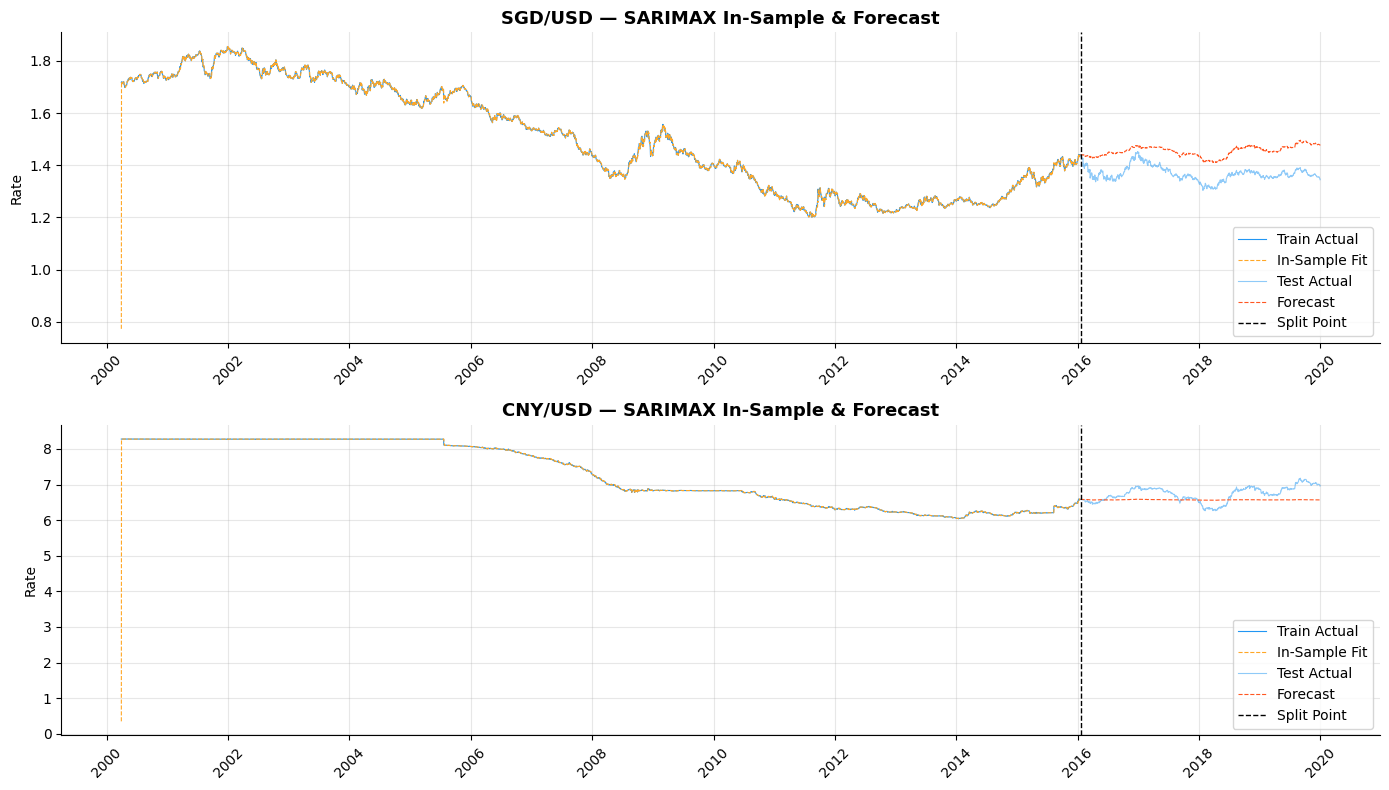

In [105]:
# Plot SARIMAX — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train["sgd_usd"].index, train["sgd_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(sarimax_train_pred_sgd.index, sarimax_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(y_test_sgd.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(sarimax_sgd_pred.index, sarimax_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — SARIMAX In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train["cny_usd"].index, train["cny_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(sarimax_train_pred_cny.index, sarimax_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(y_test_cny.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(sarimax_cny_pred.index, sarimax_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — SARIMAX In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/19_sarimax_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### SARIMAX — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.015449 | 0.089232 | 0.123712 | 0.261861 |
| MAE | 0.003645 | 0.086379 | 0.005258 | 0.220958 |
| MAPE | 0.2430% | 6.3406% | 0.0718% | 3.2390% |
| R² | 0.9941 | -9.3828 | 0.9798 | -0.5437 |
| Max Error | 0.943300 | 0.131071 | 7.932230 | 0.601688 |
| Directional Acc. | 48.65% | 67.28% | 38.01% | 66.80% |

**Key findings:**
- SARIMAX is the **first model to significantly beat 50% directional accuracy** — 67% for SGD 
  and 67% for CNY — confirming the cross-currency relationship is directionally predictive
- Adding CNY as exogenous variable improved SGD's AIC from -32266 to -32339
- Despite poor RMSE/R², the directional accuracy makes SARIMAX valuable for a bank 
  that needs to know which way the rate is moving rather than the exact value
- The singular covariance matrix warning for CNY suggests model simplification is needed

### 9.6 VAR (Vector Autoregression)

VAR is a multivariate time series model that captures the **linear interdependencies 
between multiple variables simultaneously**. Unlike ARIMA which models each currency 
independently, VAR models SGD and CNY jointly — each variable is expressed as a 
linear function of its own past values and the past values of all other variables.

The key equation for each variable is:

**SGD(t) = c₁ + α₁·SGD(t-1) + α₂·SGD(t-2) + β₁·CNY(t-1) + β₂·CNY(t-2) + ε₁**  
**CNY(t) = c₂ + γ₁·CNY(t-1) + γ₂·CNY(t-2) + δ₁·SGD(t-1) + δ₂·SGD(t-2) + ε₂**

VAR requires **stationary series** — we use the differenced series confirmed earlier.
The optimal lag order **p** is selected using AIC.

In [106]:
# VAR requires stationary (differenced) series
var_train = pd.DataFrame({
    "sgd_diff": train["sgd_usd"].diff().dropna(),
    "cny_diff": train["cny_usd"].diff().dropna()
})

print(f"VAR training data shape : {var_train.shape}")
var_train.head()

VAR training data shape : (4123, 2)


,sgd_diff,cny_diff
date,,
2000-03-30,0.002600,-0.000100
2000-03-31,-0.007400,-0.000100
2000-04-03,0.005300,-0.000100
2000-04-04,0.001000,0.000500
2000-04-05,-0.002300,0.000400


In [107]:
# VAR lag order selection using AIC
var_model = VAR(var_train)
lag_selection = var_model.select_order(maxlags=15)
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -20.60      -20.60   1.128e-09      -20.60
1       -20.62     -20.61*   1.110e-09     -20.62*
2       -20.62      -20.60   1.110e-09      -20.61
3       -20.62      -20.60   1.106e-09      -20.61
4       -20.62      -20.59   1.108e-09      -20.61
5       -20.62      -20.59   1.106e-09      -20.61
6       -20.62      -20.58   1.107e-09      -20.61
7       -20.63      -20.58   1.103e-09      -20.61
8       -20.62      -20.57   1.104e-09      -20.61
9      -20.63*      -20.57  1.102e-09*      -20.61
10      -20.63      -20.56   1.103e-09      -20.60
11      -20.62      -20.55   1.105e-09      -20.60
12      -20.62      -20.55   1.105e-09      -20.60
13      -20.62      -20.54   1.105e-09      -20.59
14      -20.62      -20.53   1.106e-09      -20.59
15      -20.62      -20.53   1.107e-09      -20.59
-------------------------------

In [108]:
# Fit VAR model with optimal lag
var_fitted = VAR(var_train).fit(maxlags=1, ic="bic")
print("✅ VAR model fitted")
print(f"Lag order selected : {var_fitted.k_ar}")

✅ VAR model fitted
Lag order selected : 1


In [109]:
# VAR model summary
print(var_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 07, Mar, 2026
Time:                     00:27:31
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -20.6143
Nobs:                     4122.00    HQIC:                  -20.6202
Log likelihood:           30813.3    FPE:                1.10490e-09
AIC:                     -20.6235    Det(Omega_mle):     1.10330e-09
--------------------------------------------------------------------
Results for equation sgd_diff
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -0.000069         0.000075           -0.921           0.357
L1.sgd_diff        -0.020532         0.015721           -1.306           0.192
L1.cny_diff        -0.000840         0.010864           -0.077   

In [110]:
# VAR — in-sample fitted values
var_fitted_values = var_fitted.fittedvalues

# Reconstruct levels from differences
sgd_actual_aligned = train["sgd_usd"].iloc[2:].values
cny_actual_aligned = train["cny_usd"].iloc[2:].values

var_train_pred_sgd = sgd_actual_aligned - var_train["sgd_diff"].iloc[1:].values + var_fitted_values["sgd_diff"].values
var_train_pred_cny = cny_actual_aligned - var_train["cny_diff"].iloc[1:].values + var_fitted_values["cny_diff"].values

var_train_pred_sgd = pd.Series(var_train_pred_sgd, index=var_train.index[1:])
var_train_pred_cny = pd.Series(var_train_pred_cny, index=var_train.index[1:])

print("── In-Sample Evaluation ────────────────────────────────")
var_train_sgd_metrics = evaluate_model(train["sgd_usd"].iloc[2:], var_train_pred_sgd, "VAR Train — SGD/USD")
print()
var_train_cny_metrics = evaluate_model(train["cny_usd"].iloc[2:], var_train_pred_cny, "VAR Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── VAR Train — SGD/USD ──────────────────────────────
RMSE               : 0.004832
MAE                : 0.003444
MAPE               : 0.2318%
R²                 : 0.999422
Max Error          : 0.035472
Directional Acc.   : 47.17%

── VAR Train — CNY/USD ──────────────────────────────
RMSE               : 0.006935
MAE                : 0.003356
MAPE               : 0.0490%
R²                 : 0.999936
Max Error          : 0.158721
Directional Acc.   : 38.41%


In [111]:
# VAR — out-of-sample forecast
# VAR forecasts differences, we need to reconstruct levels
var_test = pd.DataFrame({
    "sgd_diff": test["sgd_usd"].diff().dropna(),
    "cny_diff": test["cny_usd"].diff().dropna()
})

# Forecast differences
var_forecast = var_fitted.forecast(var_train.values[-var_fitted.k_ar:], steps=len(test))
var_forecast_df = pd.DataFrame(var_forecast, columns=["sgd_diff", "cny_diff"], index=test.index[:len(var_forecast)])

print(f"Forecast shape : {var_forecast_df.shape}")
var_forecast_df.head()

Forecast shape : (1031, 2)


,sgd_diff,cny_diff
date,,
2016-01-19,-0.000069,-0.000426
2016-01-20,-0.000068,-0.000411
2016-01-21,-0.000068,-0.000411
2016-01-22,-0.000068,-0.000411
2016-01-25,-0.000068,-0.000411


In [112]:
# Reconstruct rate levels from forecasted differences
last_sgd = train["sgd_usd"].iloc[-1]
last_cny = train["cny_usd"].iloc[-1]

var_sgd_pred = last_sgd + var_forecast_df["sgd_diff"].cumsum()
var_cny_pred = last_cny + var_forecast_df["cny_diff"].cumsum()

print(f"SGD pred shape : {var_sgd_pred.shape}")
var_sgd_pred.head()

SGD pred shape : (1031,)


date
2016-01-19   1.440231
2016-01-20   1.440163
2016-01-21   1.440095
2016-01-22   1.440028
2016-01-25   1.439960
Name: sgd_diff, dtype: float64

In [113]:
# VAR — evaluate out-of-sample SGD
var_sgd_metrics = evaluate_model(y_test_sgd, var_sgd_pred, "VAR — SGD/USD")

── VAR — SGD/USD ──────────────────────────────
RMSE               : 0.047752
MAE                : 0.039073
MAPE               : 2.8865%
R²                 : -1.973490
Max Error          : 0.100854
Directional Acc.   : 50.00%


In [114]:
# VAR — evaluate out-of-sample CNY
var_cny_metrics = evaluate_model(y_test_cny, var_cny_pred, "VAR — CNY/USD")

── VAR — CNY/USD ──────────────────────────────
RMSE               : 0.460222
MAE                : 0.374229
MAPE               : 5.4509%
R²                 : -3.768371
Max Error          : 0.983669
Directional Acc.   : 44.56%


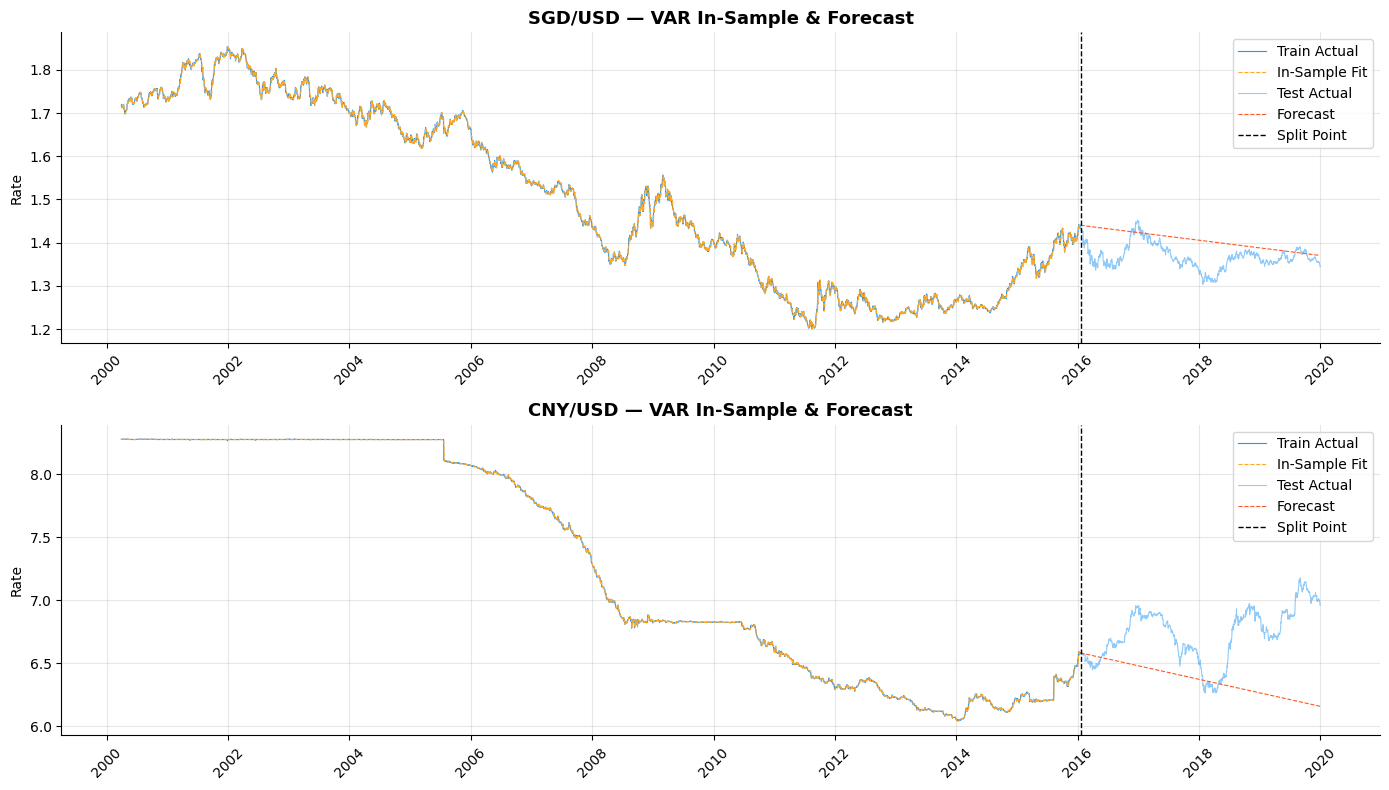

In [115]:
# Plot VAR — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train["sgd_usd"].index, train["sgd_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(var_train_pred_sgd.index, var_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(y_test_sgd.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(var_sgd_pred.index, var_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — VAR In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train["cny_usd"].index, train["cny_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(var_train_pred_cny.index, var_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(y_test_cny.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(var_cny_pred.index, var_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — VAR In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/20_var_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### VAR — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.004832 | 0.047752 | 0.006935 | 0.460222 |
| MAE | 0.003444 | 0.039073 | 0.003356 | 0.374229 |
| MAPE | 0.2318% | 2.8865% | 0.0490% | 5.4509% |
| R² | 0.9994 | -1.9735 | 0.9999 | -3.7684 |
| Max Error | 0.035472 | 0.100854 | 0.158721 | 0.983669 |
| Directional Acc. | 47.17% | 50.00% | 38.41% | 44.56% |

**Key findings:**
- SGD directional accuracy of exactly 50% — equivalent to a coin flip
- CNY forecast drifts in the wrong direction — VAR extrapolated the historical 
  downward trend but CNY reversed direction due to trade war
- VAR performs better than ARIMA/SARIMA but worse than SARIMAX
- The one-directional Granger causality (SGD → CNY but not CNY → SGD) 
  explains why VAR adds limited value for SGD forecasting

### 9.7 VECM (Vector Error Correction Model)

VECM extends VAR by incorporating **cointegration** — a long-run equilibrium 
relationship between two non-stationary series. If SGD and CNY are cointegrated, 
it means that even though both series wander over time, they cannot drift too far 
apart — they are pulled back toward a long-run equilibrium.

VECM adds an **error correction term** to the VAR equations:
- If SGD drifts too far above equilibrium → model predicts it will fall back
- If CNY drifts too far below equilibrium → model predicts it will rise back

**Requirements:**
- Both series must be I(1) — confirmed ✅
- Series must be cointegrated — we will test this using the Johansen test

VECM works on the **original levels** (not differenced) unlike VAR.

In [116]:
# Johansen cointegration test
from statsmodels.tsa.vector_ar.vecm import coint_johansen

johansen_test = coint_johansen(train[["sgd_usd", "cny_usd"]], det_order=0, k_ar_diff=1)

print("── Johansen Cointegration Test ─────────────────────────")
print("\nEigenvalues:")
print(johansen_test.eig)
print("\nTrace Statistics vs Critical Values (90%, 95%, 99%):")
print(pd.DataFrame(johansen_test.lr1, columns=["Trace Stat"], index=["r=0", "r<=1"]))
print("\nCritical Values:")
print(pd.DataFrame(johansen_test.cvt, columns=["90%", "95%", "99%"], index=["r=0", "r<=1"]))

── Johansen Cointegration Test ─────────────────────────

Eigenvalues:
[0.01186339 0.00030734]

Trace Statistics vs Critical Values (90%, 95%, 99%):
      Trace Stat
r=0    50.460314
r<=1    1.267056

Critical Values:
           90%       95%       99%
r=0  13.429400 15.494300 19.934900
r<=1  2.705500  3.841500  6.634900


In [117]:
# Fit VECM model
vecm_model = VECM(train[["sgd_usd", "cny_usd"]], 
                  k_ar_diff=1, 
                  coint_rank=1,
                  deterministic="ci")
vecm_fitted = vecm_model.fit()

print("✅ VECM model fitted")
print(vecm_fitted.summary())

✅ VECM model fitted
Det. terms outside the coint. relation & lagged endog. parameters for equation sgd_usd
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.sgd_usd    -0.0209      0.016     -1.326      0.185      -0.052       0.010
L1.cny_usd    -0.0008      0.011     -0.072      0.942      -0.022       0.021
Det. terms outside the coint. relation & lagged endog. parameters for equation cny_usd
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.sgd_usd     0.1660      0.022      7.392      0.000       0.122       0.210
L1.cny_usd    -0.0743      0.016     -4.780      0.000      -0.105      -0.044
              Loading coefficients (alpha) for equation sgd_usd               
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------

In [118]:
# VECM — in-sample fitted values
vecm_fitted_values = vecm_fitted.fittedvalues

vecm_train_pred_sgd = pd.Series(vecm_fitted_values[:, 0], index=train.index[2:])
vecm_train_pred_cny = pd.Series(vecm_fitted_values[:, 1], index=train.index[2:])

print("── In-Sample Evaluation ────────────────────────────────")
vecm_train_sgd_metrics = evaluate_model(train["sgd_usd"].iloc[2:], vecm_train_pred_sgd, "VECM Train — SGD/USD")
print()
vecm_train_cny_metrics = evaluate_model(train["cny_usd"].iloc[2:], vecm_train_pred_cny, "VECM Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── VECM Train — SGD/USD ──────────────────────────────
RMSE               : 0.004833
MAE                : 0.003443
MAPE               : 0.2317%
R²                 : 0.999422
Max Error          : 0.035504
Directional Acc.   : 47.17%

── VECM Train — CNY/USD ──────────────────────────────
RMSE               : 0.006895
MAE                : 0.003400
MAPE               : 0.0495%
R²                 : 0.999937
Max Error          : 0.158151
Directional Acc.   : 38.46%


In [119]:
# VECM — out-of-sample forecast
vecm_forecast = vecm_fitted.predict(steps=len(test))

vecm_sgd_pred = pd.Series(vecm_forecast[:, 0], index=test.index)
vecm_cny_pred = pd.Series(vecm_forecast[:, 1], index=test.index)

print(f"SGD forecast shape : {vecm_sgd_pred.shape}")
vecm_sgd_pred.head()

SGD forecast shape : (1031,)


date
2016-01-19   1.440334
2016-01-20   1.440366
2016-01-21   1.440398
2016-01-22   1.440430
2016-01-25   1.440462
dtype: float64

In [120]:
# VECM — evaluate out-of-sample SGD
vecm_sgd_metrics = evaluate_model(y_test_sgd, vecm_sgd_pred, "VECM — SGD/USD")

── VECM — SGD/USD ──────────────────────────────
RMSE               : 0.086406
MAE                : 0.081424
MAPE               : 5.9973%
R²                 : -8.735623
Max Error          : 0.146729
Directional Acc.   : 45.05%


In [121]:
# VECM — evaluate out-of-sample CNY
vecm_cny_metrics = evaluate_model(y_test_cny, vecm_cny_pred, "VECM — CNY/USD")

── VECM — CNY/USD ──────────────────────────────
RMSE               : 0.206573
MAE                : 0.151591
MAPE               : 2.2933%
R²                 : 0.039310
Max Error          : 0.570150
Directional Acc.   : 45.15%


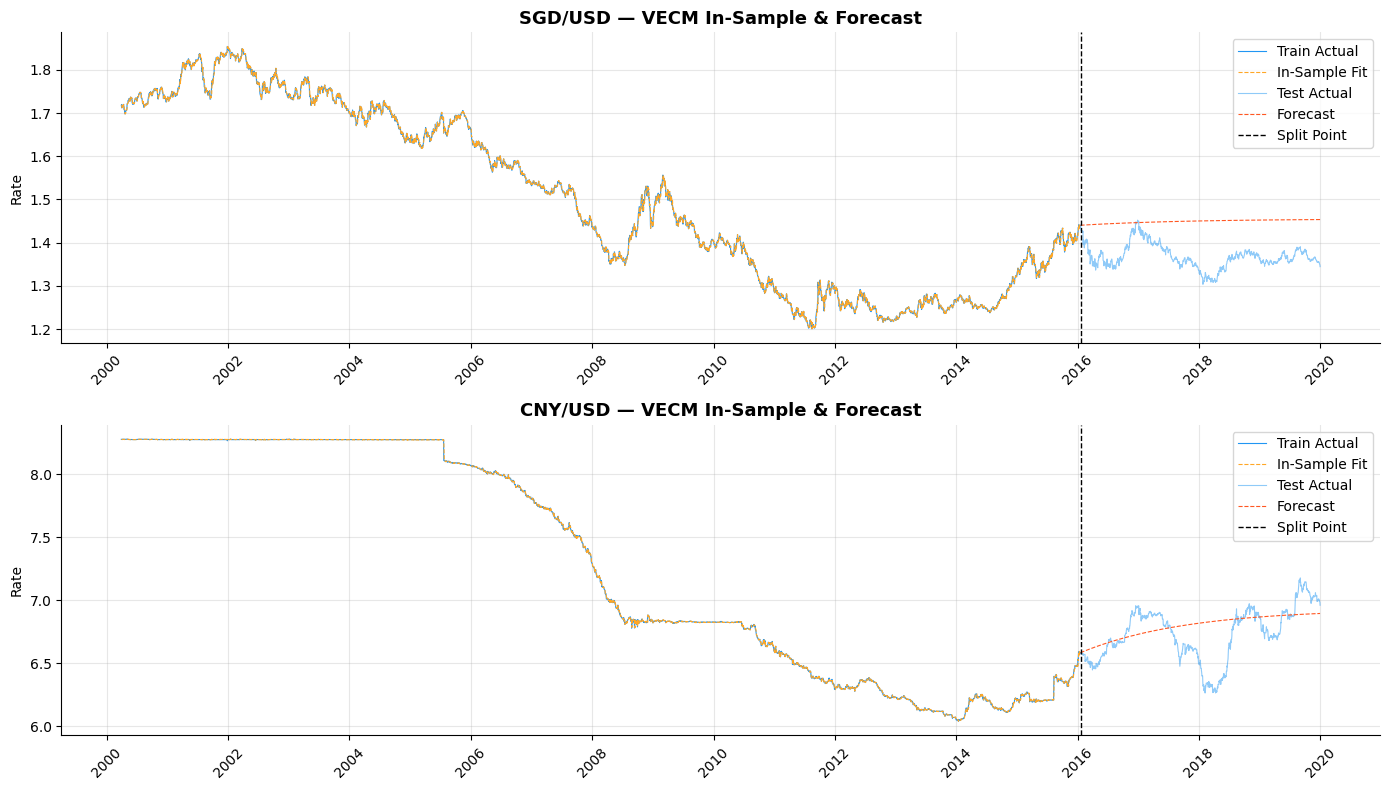

In [122]:
# Plot VECM — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train["sgd_usd"].index, train["sgd_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(vecm_train_pred_sgd.index, vecm_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(y_test_sgd.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(vecm_sgd_pred.index, vecm_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — VECM In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train["cny_usd"].index, train["cny_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(vecm_train_pred_cny.index, vecm_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(y_test_cny.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(vecm_cny_pred.index, vecm_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — VECM In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/21_vecm_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### VECM — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.004833 | 0.086406 | 0.006895 | 0.206573 |
| MAE | 0.003443 | 0.081424 | 0.003400 | 0.151591 |
| MAPE | 0.2317% | 5.9973% | 0.0495% | 2.2933% |
| R² | 0.9994 | -8.7356 | 0.9999 | 0.0393 |
| Max Error | 0.035504 | 0.146729 | 0.158151 | 0.570150 |
| Directional Acc. | 47.17% | 45.05% | 38.46% | 45.15% |

**Key findings:**
- CNY achieves first positive out-of-sample R² (0.039) among all statistical models
- The error correction term is significant for CNY (p=0.000) but not SGD (p=0.637)
- SGD leads the cointegrated relationship — CNY adjusts back to equilibrium, not SGD
- VECM outperforms VAR for CNY but underperforms for SGD
- Statistical models have reached their limit — ML models should capture 
  non-linear patterns that statistical models cannot

### 9.8 Facebook Prophet

Prophet is a forecasting framework developed by Meta (Facebook) designed for 
business time series with strong seasonal patterns and trend changes. It decomposes 
the series into three components:

- **Trend:** models non-linear growth or decline using piecewise linear segments
- **Seasonality:** captures yearly, weekly, and daily patterns using Fourier series
- **Holidays:** accounts for irregular events that cause spikes or dips

Prophet is robust to missing data, handles outliers well, and automatically detects 
**changepoints** — moments where the trend shifts direction. This makes it particularly 
interesting for our data given the structural breaks we identified in EDA (CNY peg 
removal 2005, GFC 2008, trade war 2018).

In [123]:
# Prophet requires specific column names: ds (date) and y (target)
from prophet import Prophet

prophet_train_sgd = train[["sgd_usd"]].reset_index()
prophet_train_sgd.columns = ["ds", "y"]

prophet_train_cny = train[["cny_usd"]].reset_index()
prophet_train_cny.columns = ["ds", "y"]

print(f"Prophet SGD train shape : {prophet_train_sgd.shape}")
print(f"Prophet CNY train shape : {prophet_train_cny.shape}")
prophet_train_sgd.head()

Prophet SGD train shape : (4124, 2)
Prophet CNY train shape : (4124, 2)


,ds,y
0,2000-03-29,1.716800
1,2000-03-30,1.719400
2,2000-03-31,1.712000
3,2000-04-03,1.717300
4,2000-04-04,1.718300


In [124]:
# Fit Prophet — SGD
prophet_sgd = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_sgd.fit(prophet_train_sgd)
print("✅ Prophet fitted for SGD")

00:27:33 - cmdstanpy - INFO - Chain [1] start processing
00:27:35 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet fitted for SGD


In [125]:
# Prophet SGD — model parameters
print("── Prophet SGD — Model Parameters ─────────────────────")
print(f"Changepoint prior scale  : {prophet_sgd.changepoint_prior_scale}")
print(f"Seasonality prior scale  : {prophet_sgd.seasonality_prior_scale}")
print(f"Yearly seasonality       : {prophet_sgd.yearly_seasonality}")
print(f"Weekly seasonality       : {prophet_sgd.weekly_seasonality}")
print(f"Number of changepoints   : {len(prophet_sgd.changepoints)}")
print(f"\nTop 5 changepoints detected:")
print(prophet_sgd.changepoints[:5])

── Prophet SGD — Model Parameters ─────────────────────
Changepoint prior scale  : 0.05
Seasonality prior scale  : 10.0
Yearly seasonality       : True
Weekly seasonality       : True
Number of changepoints   : 25

Top 5 changepoints detected:
132   2000-09-29
264   2001-04-03
396   2001-10-04
528   2002-04-08
660   2002-10-09
Name: ds, dtype: datetime64[us]


In [126]:
# Fit Prophet — CNY
prophet_cny = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_cny.fit(prophet_train_cny)
print("✅ Prophet fitted for CNY")

00:27:35 - cmdstanpy - INFO - Chain [1] start processing
00:27:36 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet fitted for CNY


In [127]:
# Prophet CNY — model parameters
print("── Prophet CNY — Model Parameters ─────────────────────")
print(f"Changepoint prior scale  : {prophet_cny.changepoint_prior_scale}")
print(f"Seasonality prior scale  : {prophet_cny.seasonality_prior_scale}")
print(f"Yearly seasonality       : {prophet_cny.yearly_seasonality}")
print(f"Weekly seasonality       : {prophet_cny.weekly_seasonality}")
print(f"Number of changepoints   : {len(prophet_cny.changepoints)}")
print(f"\nTop 5 changepoints detected:")
print(prophet_cny.changepoints[:5])

── Prophet CNY — Model Parameters ─────────────────────
Changepoint prior scale  : 0.05
Seasonality prior scale  : 10.0
Yearly seasonality       : True
Weekly seasonality       : True
Number of changepoints   : 25

Top 5 changepoints detected:
132   2000-09-29
264   2001-04-03
396   2001-10-04
528   2002-04-08
660   2002-10-09
Name: ds, dtype: datetime64[us]


In [128]:
# Prophet — in-sample evaluation
prophet_train_pred_sgd = prophet_sgd.predict(prophet_train_sgd)
prophet_train_pred_cny = prophet_cny.predict(prophet_train_cny)

print("── In-Sample Evaluation ────────────────────────────────")
prophet_train_sgd_metrics = evaluate_model(
    train["sgd_usd"], 
    prophet_train_pred_sgd["yhat"].values, 
    "Prophet Train — SGD/USD"
)
print()
prophet_train_cny_metrics = evaluate_model(
    train["cny_usd"], 
    prophet_train_pred_cny["yhat"].values, 
    "Prophet Train — CNY/USD"
)

── In-Sample Evaluation ────────────────────────────────
── Prophet Train — SGD/USD ──────────────────────────────
RMSE               : 0.021475
MAE                : 0.017164
MAPE               : 1.1693%
R²                 : 0.988591
Max Error          : 0.072940
Directional Acc.   : 50.81%

── Prophet Train — CNY/USD ──────────────────────────────
RMSE               : 0.042895
MAE                : 0.025437
MAPE               : 0.3869%
R²                 : 0.997569
Max Error          : 0.300770
Directional Acc.   : 44.94%


In [129]:
# Prophet — out-of-sample forecast
prophet_test_df = test[["sgd_usd"]].reset_index()[["date"]].rename(columns={"date": "ds"})

prophet_sgd_pred = prophet_sgd.predict(prophet_test_df)
prophet_cny_pred = prophet_cny.predict(prophet_test_df)

print(f"SGD forecast shape : {prophet_sgd_pred.shape}")

SGD forecast shape : (1031, 19)


In [130]:
# Prophet — evaluate out-of-sample SGD
prophet_sgd_metrics = evaluate_model(
    y_test_sgd,
    prophet_sgd_pred["yhat"].values,
    "Prophet — SGD/USD"
)

── Prophet — SGD/USD ──────────────────────────────
RMSE               : 0.158141
MAE                : 0.138426
MAPE               : 10.1866%
R²                 : -31.611165
Max Error          : 0.275258
Directional Acc.   : 48.54%


In [131]:
# Prophet — evaluate out-of-sample CNY
prophet_cny_metrics = evaluate_model(
    y_test_cny,
    prophet_cny_pred["yhat"].values,
    "Prophet — CNY/USD"
)

── Prophet — CNY/USD ──────────────────────────────
RMSE               : 0.398888
MAE                : 0.360966
MAPE               : 5.2907%
R²                 : -2.582092
Max Error          : 0.710084
Directional Acc.   : 48.64%


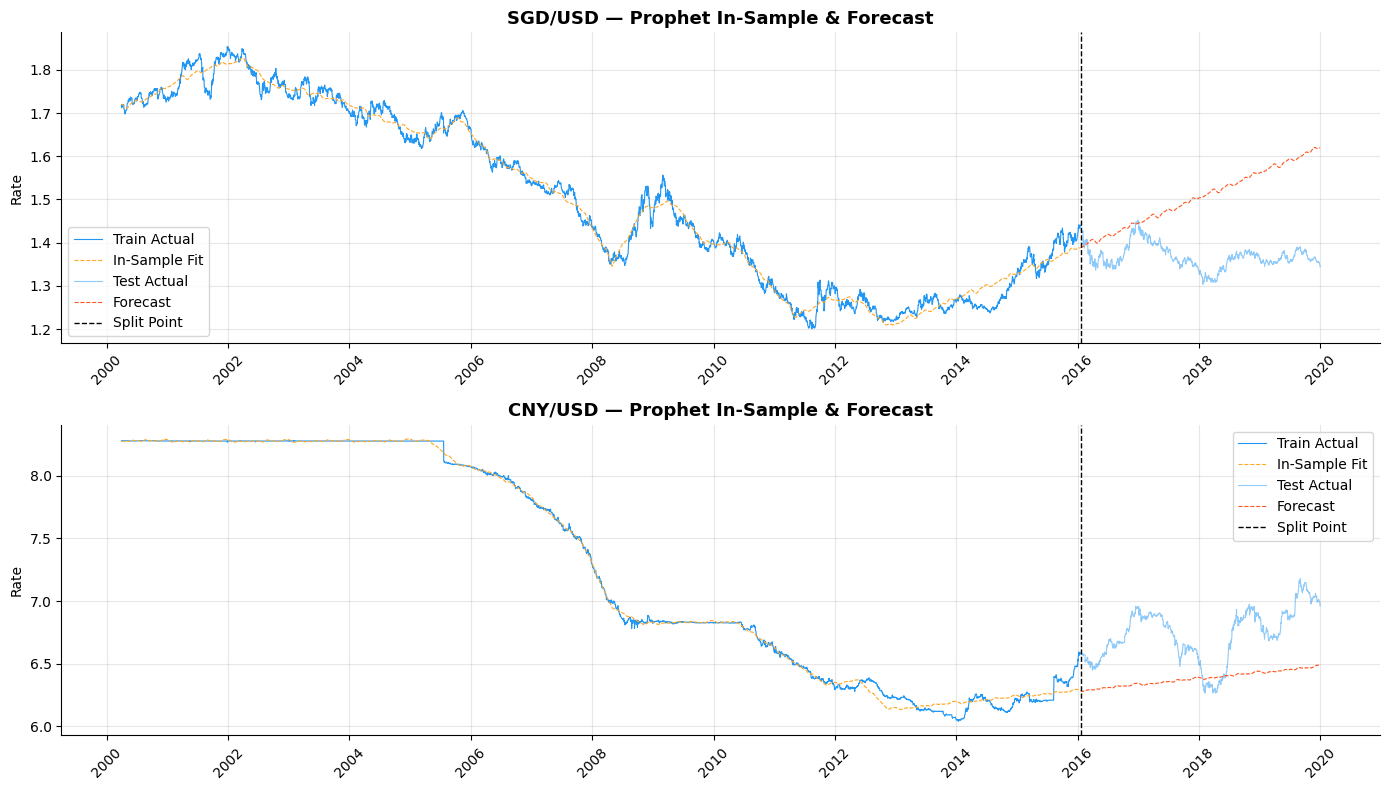

In [132]:
# Plot Prophet — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train["sgd_usd"].index, train["sgd_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(train.index, prophet_train_pred_sgd["yhat"].values, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(y_test_sgd.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(test.index, prophet_sgd_pred["yhat"].values, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — Prophet In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train["cny_usd"].index, train["cny_usd"], color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(train.index, prophet_train_pred_cny["yhat"].values, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(y_test_cny.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(test.index, prophet_cny_pred["yhat"].values, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — Prophet In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/22_prophet_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### Prophet — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.021475 | 0.158141 | 0.042895 | 0.398888 |
| MAE | 0.017164 | 0.138426 | 0.025437 | 0.360966 |
| MAPE | 1.1693% | 10.1866% | 0.3869% | 5.2907% |
| R² | 0.9886 | -31.6112 | 0.9976 | -2.5821 |
| Max Error | 0.072940 | 0.275258 | 0.300770 | 0.710084 |
| Directional Acc. | 50.81% | 48.54% | 44.94% | 48.64% |

**Key findings:**
- Prophet is the worst performing model out-of-sample for SGD (R² = -31.6)
- Both forecasts extrapolate the wrong trend direction post-2016
- Prophet is designed for business time series with stable seasonal patterns —
  forex rates with policy-driven reversals are not suited to Prophet's assumptions
- The large in-sample to out-of-sample gap confirms severe overfitting to training trends
- **Statistical modelling phase complete** — all 7 statistical models have been evaluated.
  Moving to Machine Learning models which can capture non-linear patterns.

## 10. Statistical Models — Summary

All 7 statistical models have been evaluated. Key findings:

| Model | SGD R² | CNY R² | SGD DA% | CNY DA% | SGD RMSE |
|---|---|---|---|---|---|
| Naïve | 0.9784 | 0.9942 | 46.74% | 43.15% | 0.004057 |
| Holt-Winters | -2.6756 | -26.9023 | 48.93% | 45.24% | 0.053092 |
| ARIMA | -6.8481 | -0.2969 | 4.95% | 26.60% | 0.077579 |
| SARIMA | -6.8646 | -0.2419 | 8.35% | 30.00% | 0.077661 |
| SARIMAX | -9.3828 | -0.5437 | 67.28% | 66.80% | 0.089232 |
| VAR | -1.9735 | -3.7684 | 50.00% | 44.56% | 0.047752 |
| VECM | -8.7356 | 0.0393 | 45.05% | 45.15% | 0.086406 |
| Prophet | -31.6112 | -2.5821 | 48.54% | 48.64% | 0.158141 |

**Overall conclusions:**
- Naïve baseline outperforms all statistical models on R² and RMSE
- SARIMAX achieves best directional accuracy (67%) by leveraging cross-currency relationship
- VECM is the only model to achieve positive CNY R² (0.039)
- All statistical models struggle with structural breaks and random walk behaviour
- Machine learning models in notebook 02 significantly outperform all statistical models

In [137]:
# Save statistical model predictions to CSV
predictions_stat = pd.DataFrame({
    "date": test.index[1:],  # trim to 1030 to match naive
    "actual_sgd": test["sgd_usd"].values[1:],
    "actual_cny": test["cny_usd"].values[1:],
    "naive_sgd": naive_pred_sgd.values,
    "naive_cny": naive_pred_cny.values,
    "hw_sgd": hw_sgd_pred.values[1:],
    "hw_cny": hw_cny_pred.values[1:],
    "arima_sgd": arima_sgd_pred.values[1:],
    "arima_cny": arima_cny_pred.values[1:],
    "sarima_sgd": sarima_sgd_pred.values[1:],
    "sarima_cny": sarima_cny_pred.values[1:],
    "sarimax_sgd": sarimax_sgd_pred.values[1:],
    "sarimax_cny": sarimax_cny_pred.values[1:],
    "var_sgd": var_sgd_pred.values[1:],
    "var_cny": var_cny_pred.values[1:],
    "vecm_sgd": vecm_sgd_pred.values[1:],
    "vecm_cny": vecm_cny_pred.values[1:],
    "prophet_sgd": prophet_sgd_pred["yhat"].values[1:],
    "prophet_cny": prophet_cny_pred["yhat"].values[1:],
})
predictions_stat.to_csv("./data/predictions_stat.csv", index=False)
print(f"✅ Statistical predictions saved — shape: {predictions_stat.shape}")

✅ Statistical predictions saved — shape: (1030, 19)
